In [4]:
from hapi import *
import numpy as np
from scipy import constants
import pycraf 
from astropy import units as u
import jax
import jax.numpy as jnp
from jax import jit
from hapi import partitionSum

# CRITICAL: Atmospheric physics requires high precision. 
# JAX defaults to 32-bit floats, which will destroy your exponential terms.
jax.config.update("jax_enable_x64", True)



frequencies = np.linspace(1e9, 1e12, 10000)  # Frequencies from 1 GHz to 1 THz
c = constants.c  # Speed of light in m/s
frq_GHz = frequencies / 1e9  # Convert frequencies to GHz

In [2]:
#convert 1750 GHz to cm-1
frequency_GHz = 1750  # Frequency in GHz
frequency_Hz = frequency_GHz * 1e9  # Convert GHz to Hz
wavelength_m = c / frequency_Hz  # Calculate wavelength in meters
wavelength_cm = wavelength_m * 100  # Convert meters to centimeters
wavenumber_cm_inv = 1 / wavelength_cm  # Calculate wavenumber in cm-1
print(f"Wavenumber for {frequency_GHz} GHz: {wavenumber_cm_inv:.4f} cm^-1")

Wavenumber for 1750 GHz: 58.3737 cm^-1


Let's go over H2O first

In [3]:
# 1. Define a local folder to cache the HITRAN data
db_begin('hitran_local_data')

# 2. Fetch the data from the server
# fetch(TableName, MoleculeID, IsotopologueID, nu_min, nu_max)
# Molecule 1 = H2O, Isotope 1 = Main isotope (H2_16O)
fetch('water_vapor_0_to_1000GHz', 1, 1, 0.0, 58.38)  # 58.38 cm^-1 corresponds to 1750 GHz

# 3. Extract the parameters (using standard HITRAN column names)
# Center Frequency (nu) [cm^-1]
f0_cm = np.array(getColumn('water_vapor_0_to_1000GHz', 'nu'))

# Reference Line Strength (S_ref) [cm^-1 / (molecule * cm^-2)]
S_ref = np.array(getColumn('water_vapor_0_to_1000GHz', 'sw'))

# Air-broadened half-width (gamma_air) [cm^-1 / atm]
gamma_air = np.array(getColumn('water_vapor_0_to_1000GHz', 'gamma_air'))

# Self-broadened half-width (gamma_self) [cm^-1 / atm]
gamma_self = np.array(getColumn('water_vapor_0_to_1000GHz', 'gamma_self'))

# Temperature dependence coefficient (n) [dimensionless]
n_temp = np.array(getColumn('water_vapor_0_to_1000GHz', 'n_air'))

# Lower-state energy (E'') [cm^-1]
E_lower = np.array(getColumn('water_vapor_0_to_1000GHz', 'elower'))

# Pressure shift coefficient (delta_air) [cm^-1 / atm]
delta_air = np.array(getColumn('water_vapor_0_to_1000GHz', 'delta_air'))

Using hitran_local_data

water_vapor_0_to_1000GHz
                     Lines parsed: 333

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: water_vapor_0_to_1000GHz
  65536 bytes written to hitran_local_data/water_vapor_0_to_1000GHz.data
Header written to hitran_local_data/water_vapor_0_to_1000GHz.header
END DOWNLOAD
                     Lines parsed: 333
PROCESSED


In [5]:
# Saving
np.savez_compressed('/pscratch/sd/v/valer/atmo3/atmo3/data/h2o_lines_1750GHz.npz', 
                    f0=f0_cm, S=S_ref, ga=gamma_air, 
                    gs=gamma_self, n=n_temp, E=E_lower, d=delta_air)

# Loading /pscratch/sd/v/valer/atmo3/atmo3/data
data = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/h2o_lines_1750GHz.npz')
f0_jax = jnp.asarray(data['f0'])

In [5]:
#Test on the partition function

import numpy as np
import jax.numpy as jnp
from jax import jit
import hapi

def generate_partition_grid(M, I, T_min=70.0, T_max=1000.0, step=0.5):
    """
    Generates a dense, pre-computed array of Partition Sums using HAPI.
    M: Molecule ID (e.g., 1 for H2O)
    I: Isotope ID (e.g., 1 for main isotope)
    """
    # Create the temperature grid
    T_grid = np.arange(T_min, T_max + step, step)
    
    # Sample HAPI across the entire grid
    Q_grid = np.array([hapi.partitionSum(M, I, t) for t in T_grid])
    
    # Convert to JAX arrays so they are ready for the compiler
    return jnp.asarray(T_grid), jnp.asarray(Q_grid)

# Generate the blueprint for H2O (Molecule 1, Isotope 1)
T_grid_h2o, Q_grid_h2o = generate_partition_grid(1, 1)

@jit
def partition_sum_jax(T, T_grid, Q_grid):
    """
    Fast, JIT-compiled partition sum using linear interpolation.
    """
    # jnp.interp parameters: (x_eval, x_data, y_data)
    return jnp.interp(T, T_grid, Q_grid)



Q_test = partition_sum_jax(300.0, T_grid_h2o, Q_grid_h2o)
Q_ref = partitionSum(1, 1, 300.0)

In [10]:
import numpy as np
import hapi

T_min = 200.0
T_max = 350.0
step = 0.5

T_grid = np.arange(T_min, T_max + step, step)

# 1. Fetch from HAPI
Q_H2O = np.array([hapi.partitionSum(1, 1, t) for t in T_grid])
Q_O3  = np.array([hapi.partitionSum(3, 1, t) for t in T_grid])
Q_O2  = np.array([hapi.partitionSum(7, 1, t) for t in T_grid])

# 2. Save to compressed NPZ
np.savez_compressed(
    '/pscratch/sd/v/valer/atmo3/atmo3/data/partition_functions.npz', 
    T_grid=T_grid, 
    H2O=Q_H2O, 
    O3=Q_O3, 
    O2=Q_O2
)


In [11]:
import jax.numpy as jnp
from jax import jit
import numpy as np

# =====================================================================
# A. Global Initialization (Runs once when the script loads)
# =====================================================================
_q_data = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/partition_functions.npz')

# Cast to JAX arrays immediately so they live on the GPU/CPU device
_T_grid_jax = jnp.asarray(_q_data['T_grid'])
_Q_grids = {
    'H2O': jnp.asarray(_q_data['H2O']),
    'O3':  jnp.asarray(_q_data['O3']),
    'O2':  jnp.asarray(_q_data['O2'])
}

# =====================================================================
# B. The JAX Math Core
# =====================================================================
@jit
def _partition_sum_jax_core(T, T_grid, Q_grid):
    """
    The pure math function. JAX compiles this down to hyper-fast machine code.
    """
    return jnp.interp(T, T_grid, Q_grid)

# =====================================================================
# C. The Python API (What you actually call)
# =====================================================================
def get_partition_sum(T, molecule):
    """
    Retrieves the interpolated partition sum for a specific molecule.
    
    Parameters:
    T : float or jax array
        The temperature in Kelvin.
    molecule : str
        'H2O', 'O3', or 'O2'
    """
    if molecule not in _Q_grids:
        raise ValueError(f"Molecule '{molecule}' not found in partition archive.")
        
    # Look up the pre-loaded array
    Q_grid_for_molecule = _Q_grids[molecule]
    
    # Pass arrays to the compiled core
    return _partition_sum_jax_core(T, _T_grid_jax, Q_grid_for_molecule)

In [13]:
print(_T_grid_jax.shape)

(301,)


In [12]:
Q_test = get_partition_sum(300.0, 'H2O')
Q_ref = hapi.partitionSum(1, 1, 300.0)
print(f"Partition Sum at 300 K (JAX): {Q_test:.4e}")
print(f"Partition Sum at 300 K (Reference): {Q_ref:.4e}")

Partition Sum at 300 K (JAX): 1.7812e+02
Partition Sum at 300 K (Reference): 1.7812e+02


In [15]:
# Let's print a few values to verify
for T in [210, 230.0, 250.0, 270, 300.0]:
    Q_jax = Q_test = get_partition_sum(T, 'H2O')
    Q_ref = hapi.partitionSum(1, 1, T)
    print(f"T={T:.1f} K: Q_jax={Q_jax:.4e}, Q_ref={Q_ref:.4e}")

T=210.0 K: Q_jax=1.0472e+02, Q_ref=1.0472e+02
T=230.0 K: Q_jax=1.1987e+02, Q_ref=1.1987e+02
T=250.0 K: Q_jax=1.3570e+02, Q_ref=1.3570e+02
T=270.0 K: Q_jax=1.5219e+02, Q_ref=1.5219e+02
T=300.0 K: Q_jax=1.7812e+02, Q_ref=1.7812e+02


In [ ]:
data_H2O_lines = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/h2o_lines_1750GHz.npz')

data_partition_functions = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/partition_functions.npz')

In [ ]:
import jax
import jax.numpy as jnp
from jax import jit
from hapi import partitionSum

# CRITICAL: Atmospheric physics requires high precision. 
# JAX defaults to 32-bit floats, which will destroy your exponential terms.
jax.config.update("jax_enable_x64", True)

# =====================================================================
# 1. JIT-Compiled Physics Sub-Modules
# =====================================================================

@jit
def compute_line_strength_jax(T, T_ref, f0_cm, S_ref, E_lower, Q_ratio):
    """ Step A: Temperature-Adjusted Line Strength S(T) """
    c2 = 1.4387770  # hc/k_B in [cm * K]
    
    boltz_factor = jnp.exp(-c2 * E_lower * ((1.0 / T) - (1.0 / T_ref)))
    
    stim_T = 1.0 - jnp.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - jnp.exp(-c2 * f0_cm / T_ref)
    
    return S_ref * Q_ratio * boltz_factor * (stim_T / stim_ref)

@jit
def compute_line_width_cm_jax(T, P_hPa, P_water_hPa, gamma_air, gamma_self, n_temp):
    """ Step B: Pressure and Temperature Broadened Line Width (gamma) """
    P_atm = P_hPa / 1013.25
    P_water_atm = P_water_hPa / 1013.25
    P_dry_atm = P_atm - P_water_atm
    
    temp_scaling = (296.0 / T) ** n_temp
    broadening = (gamma_air * P_dry_atm) + (gamma_self * P_water_atm)
    
    return temp_scaling * broadening

@jit
def compute_line_shift_cm_jax(P_hPa, f0_cm, delta_air):
    """ Step C: Pressure-Induced Line Shift (nu*) """
    P_atm = P_hPa / 1013.25
    return f0_cm + (delta_air * P_atm)

@jit
def compute_vvh_750_jax(nu, nu_star, gamma, T):
    """ Step D: Van Vleck-Huber Line Shape with 750 GHz Cutoff """
    c2 = 1.4387770
    cutoff_cm = 750.0 / 29.9792458
    
    rad_factor = (nu / nu_star) * (jnp.tanh(c2 * nu / (2.0 * T)) / jnp.tanh(c2 * nu_star / (2.0 * T)))
    
    delta_nu_minus = nu - nu_star
    delta_nu_plus  = nu + nu_star
    
    F_L_minus = (1.0 / jnp.pi) * (gamma / (delta_nu_minus**2 + gamma**2))
    F_L_plus  = (1.0 / jnp.pi) * (gamma / (delta_nu_plus**2 + gamma**2))
    
    # jnp.where works exactly like np.where, but compiles down to efficient XLA ops
    F_L_minus = jnp.where(jnp.abs(delta_nu_minus) <= cutoff_cm, F_L_minus, 0.0)
    F_L_plus  = jnp.where(jnp.abs(delta_nu_plus) <= cutoff_cm, F_L_plus, 0.0)
    
    return rad_factor * (F_L_minus + F_L_plus)


# =====================================================================
# 2. The Master JAX Recombination Function
# =====================================================================

@jit 
def _calculate_h2o_absorption_jax_core(
    freq_grid_GHz, T, T_ref, P_hPa, P_water_hPa, Q_ratio,
    f0_cm, S_ref, gamma_air, gamma_self, n_temp, E_lower, delta_air
):
    """The purely compiled JAX core that handles the heavy array math."""
    nu_grid_cm = freq_grid_GHz / 29.9792458
    
    # Broadcasting: (N_freqs, 1) and (1, N_lines)
    nu = nu_grid_cm[:, None]
    
    _f0 = f0_cm[None, :]
    _S_ref = S_ref[None, :]
    _ga = gamma_air[None, :]
    _gs = gamma_self[None, :]
    _n = n_temp[None, :]
    _E = E_lower[None, :]
    _d = delta_air[None, :]
    
    S_T = compute_line_strength_jax(T, T_ref, _f0, _S_ref, _E, Q_ratio)
    gamma = compute_line_width_cm_jax(T, P_hPa, P_water_hPa, _ga, _gs, _n)
    nu_star = compute_line_shift_cm_jax(P_hPa, _f0, _d)
    
    F_VVH = compute_vvh_750_jax(nu, nu_star, gamma, T)
    
    # Summing across the line dimension
    return jnp.sum(S_T * F_VVH, axis=1)


# =====================================================================
# 3. The Python Bridge (Safe Entry Point)
# =====================================================================

def calculate_molecular_absorption_coefficient_jax(
    freq_grid_GHz, T, P_hPa, P_water_hPa, 
    f0_cm, S_ref, gamma_air, gamma_self, n_temp, E_lower, delta_air
):
    """
    The safe entry wrapper. It calculates HAPI quantities in Python, 
    then passes them to the hyper-fast JAX compiled core.
    """
    T_ref = 296.0
    
    # 1. HAPI runs strictly in standard Python
    Q_ref = partitionSum(1, 1, T_ref)
    Q_T = partitionSum(1, 1, T)
    Q_ratio = Q_ref / Q_T
    
    # 2. Ensure parameter arrays are JAX arrays (optional but good practice)
    # JAX will automatically cast numpy arrays, but explicit casting is safer.
    f0_jax = jnp.asarray(f0_cm)
    S_ref_jax = jnp.asarray(S_ref)
    ga_jax = jnp.asarray(gamma_air)
    gs_jax = jnp.asarray(gamma_self)
    n_jax = jnp.asarray(n_temp)
    E_jax = jnp.asarray(E_lower)
    d_jax = jnp.asarray(delta_air)
    freq_grid_jax = jnp.asarray(freq_grid_GHz)
    
    # 3. Trigger the compiled JAX function
    k_nu = _calculate_h2o_absorption_jax_core(
        freq_grid_jax, T, T_ref, P_hPa, P_water_hPa, Q_ratio,
        f0_jax, S_ref_jax, ga_jax, gs_jax, n_jax, E_jax, d_jax
    )
    
    return k_nu

In [16]:
import numpy as np
from hapi import partitionSum

# =====================================================================
# 1. Physics Sub-Modules (The am / HITRAN equations)
# =====================================================================

def compute_line_strength(T, f0_cm, S_ref, E_lower):
    """ Step A: Temperature-Adjusted Line Strength S(T) """
    T_ref = 296.0
    c2 = 1.4387770  # hc/k_B in [cm * K]
    
    # Partition sums for H2O (Molecule 1, Isotope 1)
    Q_ratio = partitionSum(1, 1, T_ref) / partitionSum(1, 1, T)
    
    boltz_factor = np.exp(-c2 * E_lower * ((1.0 / T) - (1.0 / T_ref)))
    
    stim_T = 1.0 - np.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - np.exp(-c2 * f0_cm / T_ref)
    
    return S_ref * Q_ratio * boltz_factor * (stim_T / stim_ref)

def compute_line_width_cm(T, P_hPa, P_water_hPa, gamma_air, gamma_self, n_temp):
    """ Step B: Pressure and Temperature Broadened Line Width (gamma) """
    P_atm = P_hPa / 1013.25
    P_water_atm = P_water_hPa / 1013.25
    P_dry_atm = P_atm - P_water_atm
    
    temp_scaling = (296.0 / T) ** n_temp
    broadening = (gamma_air * P_dry_atm) + (gamma_self * P_water_atm)
    
    # Return directly in cm^-1
    return temp_scaling * broadening

def compute_line_shift_cm(P_hPa, f0_cm, delta_air):
    """ Step C: Pressure-Induced Line Shift (nu*) """
    P_atm = P_hPa / 1013.25
    return f0_cm + (delta_air * P_atm)

def compute_vvh_750(nu, nu_star, gamma, T):
    """ Step D: Van Vleck-Huber Line Shape with 750 GHz Cutoff """
    c2 = 1.4387770
    cutoff_cm = 750.0 / 29.9792458  # 750 GHz converted to cm^-1
    
    # 1. Detailed balance radiation factor
    rad_factor = (nu / nu_star) * (np.tanh(c2 * nu / (2.0 * T)) / np.tanh(c2 * nu_star / (2.0 * T)))
    
    # 2. Resonances (Matrix Broadcasting happens here!)
    delta_nu_minus = nu - nu_star
    delta_nu_plus  = nu + nu_star
    
    # 3. Base Lorentz profiles
    F_L_minus = (1.0 / np.pi) * (gamma / (delta_nu_minus**2 + gamma**2))
    F_L_plus  = (1.0 / np.pi) * (gamma / (delta_nu_plus**2 + gamma**2))
    
    # 4. Apply 750 GHz Cutoff
    F_L_minus = np.where(np.abs(delta_nu_minus) <= cutoff_cm, F_L_minus, 0.0)
    F_L_plus  = np.where(np.abs(delta_nu_plus) <= cutoff_cm, F_L_plus, 0.0)
    
    return rad_factor * (F_L_minus + F_L_plus)


# =====================================================================
# 2. The Master Recombination Function
# =====================================================================

def calculate_molecular_absorption_coefficient(
    freq_grid_GHz, T, P_hPa, P_water_hPa, 
    f0_cm, S_ref, gamma_air, gamma_self, n_temp, E_lower, delta_air
):
    """
    Computes the total molecular absorption coefficient k(nu) for a specific atmospheric layer.
    
    Returns:
    k_nu : Array of cross-sections [cm^2 / molecule] matching the freq_grid shape.
    """
    
    # 1. Ensure the frequency grid is converted to wavenumbers [cm^-1]
    nu_grid_cm = freq_grid_GHz / 29.9792458
    
    # 2. Setup Matrix Broadcasting
    # Convert the frequency grid to a column vector: shape (N_freqs, 1)
    nu = nu_grid_cm[:, None]
    
    # Convert HITRAN line parameters to row vectors: shape (1, N_lines)
    _f0 = f0_cm[None, :]
    _S_ref = S_ref[None, :]
    _ga = gamma_air[None, :]
    _gs = gamma_self[None, :]
    _n = n_temp[None, :]
    _E = E_lower[None, :]
    _d = delta_air[None, :]
    
    # 3. Execute the Physics Pipeline
    # Calculate S_i(T) -> shape: (1, N_lines)
    S_T = compute_line_strength(T, _f0, _S_ref, _E)
    
    # Calculate gamma_i -> shape: (1, N_lines)
    gamma = compute_line_width_cm(T, P_hPa, P_water_hPa, _ga, _gs, _n)
    
    # Calculate nu*_i -> shape: (1, N_lines)
    nu_star = compute_line_shift_cm(P_hPa, _f0, _d)
    
    # Calculate F_i(nu) -> shape: (N_freqs, N_lines)
    F_VVH = compute_vvh_750(nu, nu_star, gamma, T)
    
    # 4. Final Equation (Eq 3.2 from am manual)
    # k(nu) = Sum_i [ S_i(T) * F_i(nu) ]
    # We sum across axis 1 (the lines dimension), leaving an array of shape (N_freqs,)
    k_nu = np.sum(S_T * F_VVH, axis=1)
    
    return k_nu

In [17]:
import jax
import jax.numpy as jnp
from jax import jit
import numpy as np

# CRITICAL: Atmospheric physics requires high precision. 
# JAX defaults to 32-bit floats, which will destroy your exponential terms.
jax.config.update("jax_enable_x64", True)

# =====================================================================
# A. Global Initialization
# =====================================================================
# We load the NPZ files into memory once at the top of the script.
# The arrays will be extracted locally inside the functions when needed.
data_H2O_lines = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/h2o_lines_1750GHz.npz')
data_partition_functions = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/partition_functions.npz')


# =====================================================================
# 1. JIT-Compiled Physics Sub-Modules
# =====================================================================

@jit
def partition_sum_jax(T):
    """ Fast, JIT-compiled partition sum using linear interpolation. """
    T_grid = jnp.asarray(data_partition_functions['T_grid'])  # Temperature grid [K]
    Q_grid = jnp.asarray(data_partition_functions['H2O'])     # H2O Partition Sum [dimensionless]
    
    return jnp.interp(T, T_grid, Q_grid)

@jit
def compute_line_strength_jax(T, T_ref, Q_ratio):
    """ Step A: Temperature-Adjusted Line Strength S(T) """
    f0_cm = jnp.asarray(data_H2O_lines['f0'])[None, :]        # Center Frequency [cm^-1]
    S_ref = jnp.asarray(data_H2O_lines['S'])[None, :]         # Reference Line Strength [cm^-1 / (molecule * cm^-2)]
    E_lower = jnp.asarray(data_H2O_lines['E'])[None, :]       # Lower-state energy [cm^-1]
    
    c2 = 1.4387770  # hc/k_B [cm * K]
    
    boltz_factor = jnp.exp(-c2 * E_lower * ((1.0 / T) - (1.0 / T_ref)))
    
    stim_T = 1.0 - jnp.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - jnp.exp(-c2 * f0_cm / T_ref)
    
    return S_ref * Q_ratio * boltz_factor * (stim_T / stim_ref)

@jit
def compute_line_width_cm_jax(T, P_hPa, P_water_hPa):
    """ Step B: Pressure and Temperature Broadened Line Width (gamma) """
    gamma_air = jnp.asarray(data_H2O_lines['ga'])[None, :]    # Air-broadened half-width [cm^-1 / atm]
    gamma_self = jnp.asarray(data_H2O_lines['gs'])[None, :]   # Self-broadened half-width [cm^-1 / atm]
    n_temp = jnp.asarray(data_H2O_lines['n'])[None, :]        # Temperature dependence coefficient [dimensionless]
    
    P_atm = P_hPa / 1013.25
    P_water_atm = P_water_hPa / 1013.25
    P_dry_atm = P_atm - P_water_atm
    
    temp_scaling = (296.0 / T) ** n_temp
    broadening = (gamma_air * P_dry_atm) + (gamma_self * P_water_atm)
    
    return temp_scaling * broadening

@jit
def compute_line_shift_cm_jax(P_hPa):
    """ Step C: Pressure-Induced Line Shift (nu*) """
    f0_cm = jnp.asarray(data_H2O_lines['f0'])[None, :]        # Center Frequency [cm^-1]
    delta_air = jnp.asarray(data_H2O_lines['d'])[None, :]     # Pressure shift coefficient [cm^-1 / atm]
    
    P_atm = P_hPa / 1013.25
    return f0_cm + (delta_air * P_atm)

@jit
def compute_vvh_750_jax(nu, nu_star, gamma, T):
    """ Step D: Van Vleck-Huber Line Shape with 750 GHz Cutoff """
    c2 = 1.4387770
    cutoff_cm = 750.0 / 29.9792458
    
    rad_factor = (nu / nu_star) * (jnp.tanh(c2 * nu / (2.0 * T)) / jnp.tanh(c2 * nu_star / (2.0 * T)))
    
    delta_nu_minus = nu - nu_star
    delta_nu_plus  = nu + nu_star
    
    F_L_minus = (1.0 / jnp.pi) * (gamma / (delta_nu_minus**2 + gamma**2))
    F_L_plus  = (1.0 / jnp.pi) * (gamma / (delta_nu_plus**2 + gamma**2))
    
    F_L_minus = jnp.where(jnp.abs(delta_nu_minus) <= cutoff_cm, F_L_minus, 0.0)
    F_L_plus  = jnp.where(jnp.abs(delta_nu_plus) <= cutoff_cm, F_L_plus, 0.0)
    
    return rad_factor * (F_L_minus + F_L_plus)


# =====================================================================
# 2. The Master JAX Recombination Function
# =====================================================================

@jit 
def _calculate_h2o_absorption_jax_core(freq_grid_GHz, T, T_ref, P_hPa, P_water_hPa, Q_ratio):
    """The purely compiled JAX core that handles the heavy array math."""
    nu_grid_cm = freq_grid_GHz / 29.9792458
    
    # Grid column vector: (N_freqs, 1)
    nu = nu_grid_cm[:, None]
    
    # Execute the Physics Pipeline
    S_T = compute_line_strength_jax(T, T_ref, Q_ratio)
    gamma = compute_line_width_cm_jax(T, P_hPa, P_water_hPa)
    nu_star = compute_line_shift_cm_jax(P_hPa)
    
    F_VVH = compute_vvh_750_jax(nu, nu_star, gamma, T)
    
    # Summing across the line dimension
    return jnp.sum(S_T * F_VVH, axis=1)


# =====================================================================
# 3. The Python API (Safe Entry Point)
# =====================================================================

def calculate_h2o_absorption_jax(freq_grid_GHz, T, P_hPa, P_water_hPa):
    """
    The main user-facing function. Only requires environmental parameters.
    """
    T_ref = 296.0
    
    # 1. Native JAX Partition Sum Evaluation
    Q_ref = partition_sum_jax(T_ref)
    Q_T = partition_sum_jax(T)
    Q_ratio = Q_ref / Q_T
    
    # 2. Ensure input grid is cast to JAX
    freq_grid_jax = jnp.asarray(freq_grid_GHz)
    
    # 3. Trigger the compiled JAX function
    k_nu = _calculate_h2o_absorption_jax_core(
        freq_grid_jax, T, T_ref, P_hPa, P_water_hPa, Q_ratio
    )
    
    return k_nu

In [18]:
P = 500.0 # Total pressure in hPa
T = 270.0 # Ambient temperature in Kelvin
P_water = 10.0 # Partial pressure of water vapor in hPa (just to ignore self-broadening for this example)


# 1. Run the function to get the cross-section
k_nu = calculate_molecular_absorption_coefficient(
    frequencies/1e9, T, P, P_water, 
    f0_cm, S_ref, gamma_air, gamma_self, n_temp, E_lower, delta_air
)

k_nu_jax = calculate_h2o_absorption_jax(frequencies/1e9, T, P, P_water)

# 2. Calculate the local molecular number density [molecules / cm^3]
# Ideal gas law: n = P / (k_B * T)
n_water_density = P_water *100 / (constants.k * T) * 1e-6 # Convert from hPa to atm and from m^3 to cm^3

# 3. Convert to Specific Attenuation [dB/km]
# alpha [Np/cm] = n_water_density * k_nu
# 10^5 converts cm to km, 4.3429 converts Nepers to Decibels
gamma_lines_dB_km = n_water_density * k_nu * 1e5 * 4.3429

gamma_lines_dB_km_jax = n_water_density * k_nu_jax * 1e5 * 4.3429

Max difference between NumPy and JAX results: 1.591616e-09 dB/km


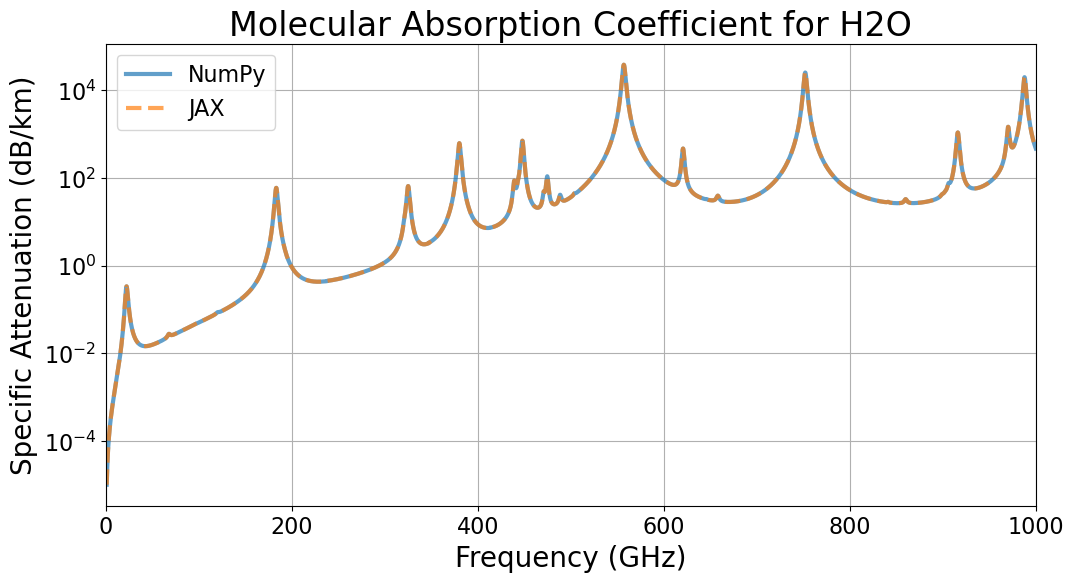

In [19]:
# Let's compare the jax and numpy results to ensure they match (they should be very close)
difference = np.abs(gamma_lines_dB_km - gamma_lines_dB_km_jax)
print(f"Max difference between NumPy and JAX results: {np.max(difference):.6e} dB/km")  

import matplotlib.pyplot as plt
import numpy as np

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

#We'll also want to plot the results to visually confirm they match and look reasonable
plt.figure(figsize=(12, 6))
plt.plot(frequencies/1e9, gamma_lines_dB_km, label='NumPy', alpha=0.7)
plt.plot(frequencies/1e9, gamma_lines_dB_km_jax, label='JAX', alpha=0.7, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Specific Attenuation (dB/km)')
plt.title('Molecular Absorption Coefficient for H2O')
plt.legend()
plt.grid()
plt.xlim(0, 1000)
plt.yscale('log')  # Log scale to better visualize the wide range of values
plt.show()

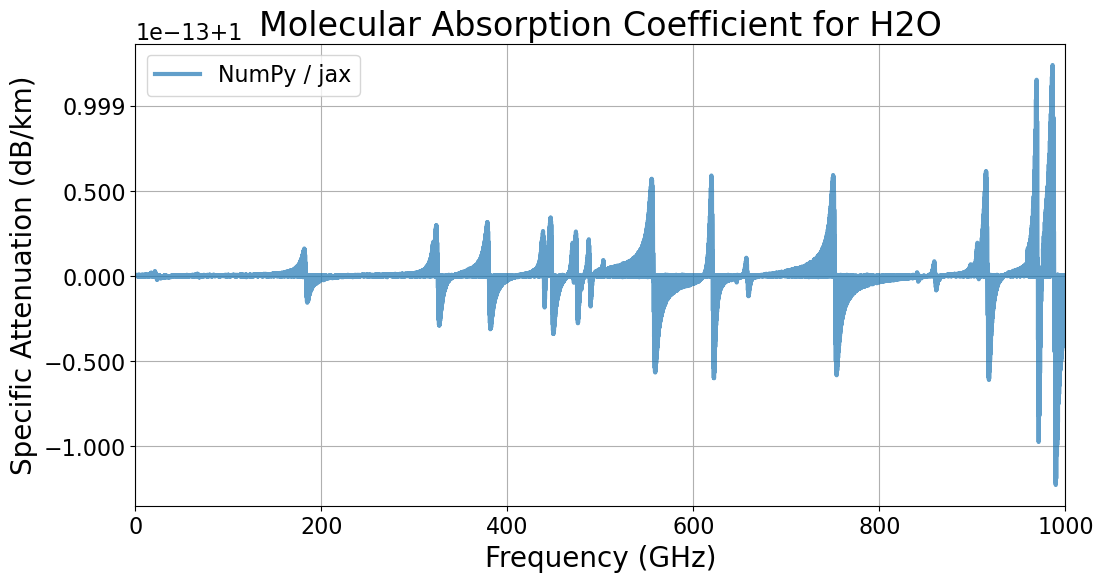

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(frequencies/1e9, gamma_lines_dB_km / gamma_lines_dB_km_jax, label='NumPy / jax', alpha=0.7)
#plt.plot(frequencies/1e9, gamma_lines_dB_km_jax / gamma_lines_jax, label='JAX', alpha=0.7, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Specific Attenuation (dB/km)')
plt.title('Molecular Absorption Coefficient for H2O')
plt.legend()
plt.grid()
plt.xlim(0, 1000)
#plt.yscale('log')  # Log scale to better visualize the wide range of values
plt.show()

H2O continuum

In [20]:
import re
import numpy as np

def list_c_arrays(filepath):
    """Scans a C file and returns the names of all hardcoded double arrays."""
    with open(filepath, 'r') as f:
        content = f.read()
        
    # Look for patterns like: double my_array[] = {
    pattern = r"double\s+([a-zA-Z0-9_]+)(?:\[.*?\])?\s*=\s*\{"
    return re.findall(pattern, content)

# Point this to your extracted src directory
h2o_file = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/h2o_continuum.c'
mt_ckd_file = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/mt_ckd.c'

print("Arrays in h2o_continuum.c:", list_c_arrays(h2o_file))
print("Arrays in mt_ckd.c:", list_c_arrays(mt_ckd_file))

Arrays in h2o_continuum.c: []
Arrays in mt_ckd.c: ['mt_ckd_for_absco_ref', 'mt_ckd_self_absco_ref', 'mt_ckd_self_texp', 'mt_ckd_wavenumbers']


In [21]:
def extract_c_array(filepath, array_name):
    """Extracts the numbers from a specific C array into a NumPy array."""
    with open(filepath, 'r') as f:
        content = f.read()
        
    # Match the specific array and grab everything between the curly braces
    pattern = rf"double\s+{array_name}(?:\[.*?\])?\s*=\s*\{{([^}}]+)\}}"
    match = re.search(pattern, content, re.DOTALL)
    
    if not match:
        raise ValueError(f"Could not find array '{array_name}' in the file.")
        
    raw_numbers = match.group(1)
    # Find all valid floating-point numbers (handles negatives and scientific notation)
    number_strings = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", raw_numbers)
    
    return np.array(number_strings, dtype=float)

# The path to your mt_ckd.c file
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/mt_ckd.c'

# Extract the arrays using the names you just discovered!
nu_grid_cm  = extract_c_array(c_file_path, 'mt_ckd_wavenumbers')
Cs_296      = extract_c_array(c_file_path, 'mt_ckd_self_absco_ref')
Cf_296      = extract_c_array(c_file_path, 'mt_ckd_for_absco_ref')
T_exp       = extract_c_array(c_file_path, 'mt_ckd_self_texp')

print(f"Extracted {len(nu_grid_cm)} data points for the continuum grid.")

Extracted 53 data points for the continuum grid.


In [32]:
print(nu_grid_cm)  # Print the first 10 wavenumbers to verify

[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]


In [22]:
import numpy as np
import re

# ... [insert your extract_c_array function here] ...

c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/mt_ckd.c'

nu_grid_cm_full  = extract_c_array(c_file_path, 'mt_ckd_wavenumbers')
Cs_296_full      = extract_c_array(c_file_path, 'mt_ckd_self_absco_ref')
Cf_296_full      = extract_c_array(c_file_path, 'mt_ckd_for_absco_ref')
T_exp_full       = extract_c_array(c_file_path, 'mt_ckd_self_texp')

# Create a mask to only keep data up to 100 cm^-1 (approx 3 THz)
mask = nu_grid_cm_full <= 100.0

nu_grid_cm = nu_grid_cm_full[mask]
Cs_296     = Cs_296_full[mask]
Cf_296     = Cf_296_full[mask]
T_exp      = T_exp_full[mask]

print(f"Truncated continuum grid to {len(nu_grid_cm)} points.")

# Save to archive
np.savez_compressed(
    '/pscratch/sd/v/valer/atmo3/atmo3/data/mt_ckd_continuum.npz',
    nu=nu_grid_cm,
    Cs=Cs_296,
    Cf=Cf_296,
    Texp=T_exp
)

Truncated continuum grid to 11 points.


In [23]:
import jax
import jax.numpy as jnp
from jax import jit
import numpy as np

jax.config.update("jax_enable_x64", True)

# =====================================================================
# A. Global Initialization
# =====================================================================
data_mt_ckd = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/mt_ckd_continuum.npz')

# =====================================================================
# B. JIT-Compiled Physics Function
# =====================================================================

@jit
def compute_h2o_continuum_jax(freq_GHz, T):
    """
    Computes the MT_CKD self and air continuum coefficients in cm^5.
    
    freq_GHz : 1D array of frequencies [GHz]
    T        : Ambient temperature [K]
    """
    # 1. Extract static arrays into the JAX tracer 
    nu_ckd  = jnp.asarray(data_mt_ckd['nu'])    # MT_CKD Wavenumber grid [cm^-1]
    C_s_296 = jnp.asarray(data_mt_ckd['Cs'])    # MT_CKD Self-broadening reference [cm^2 / molecule]
    C_f_296 = jnp.asarray(data_mt_ckd['Cf'])    # MT_CKD Foreign-broadening reference [cm^2 / molecule]
    T_exp   = jnp.asarray(data_mt_ckd['Texp'])  # MT_CKD Self-broadening temperature exponent [dimensionless]
    
    c2 = 1.4387770  # Second radiation constant [cm * K]
    n_ref = 2.479e19  # Reference density at 1 atm and 296K [molecules / cm^3]
    
    nu_cm = freq_GHz / 29.9792458
    
    # 2. Interpolate the MT_CKD tables to our frequency grid
    # jnp.interp signature is (x_eval, x_data, y_data)
    Cs_296_interp = jnp.interp(nu_cm, nu_ckd, C_s_296)
    Cf_296_interp = jnp.interp(nu_cm, nu_ckd, C_f_296)
    Texp_interp   = jnp.interp(nu_cm, nu_ckd, T_exp)
    
    # 3. Apply Temperature Scaling
    # Self continuum exponential scaling
    Cs_T = Cs_296_interp * jnp.exp(Texp_interp * ((1.0 / T) - (1.0 / 296.0)))
    
    # Foreign continuum (independent of T in base MT_CKD)
    Cf_T = Cf_296_interp
    
    # 4. Compute Detailed Balance Radiation Term
    rad_term = nu_cm * jnp.tanh((c2 * nu_cm) / (2.0 * T))
    
    # 5. Final coefficients in cm^5
    k_self_cm5 = (rad_term * Cs_T) / n_ref
    k_air_cm5  = (rad_term * Cf_T) / n_ref
    
    return k_self_cm5, k_air_cm5

In [24]:
import numpy as np

def compute_k_cm5(freq_GHz, T, nu_ckd, C_s_296, C_f_296, T_exp):
    """
    Computes the MT_CKD self and air continuum coefficients in cm^5.
    
    Inputs:
    freq_GHz  : Array of frequencies to evaluate [GHz]
    T         : Ambient temperature [K]
    nu_ckd    : MT_CKD Wavenumber grid [cm^-1]
    C_s_296   : MT_CKD Self-broadening reference table
    C_f_296   : MT_CKD Foreign-broadening reference table
    T_exp     : MT_CKD Self-broadening temperature exponent table
    
    Returns:
    k_self_cm5, k_air_cm5
    """
    c2 = 1.4387770  # Second radiation constant [cm*K]
    # Reference density at 1 atm and 296K
    n_ref = 2.479e19  
    nu_cm = freq_GHz / 29.9792458
    
    # 1. Interpolate the MT_CKD tables to our frequency grid
    Cs_296_interp = np.interp(nu_cm, nu_ckd, C_s_296)
    Cf_296_interp = np.interp(nu_cm, nu_ckd, C_f_296)
    Texp_interp   = np.interp(nu_cm, nu_ckd, T_exp)
    
    # 2. Apply Temperature Scaling
    # Self continuum exponential scaling
    Cs_T = Cs_296_interp * np.exp(Texp_interp * ((1.0 / T) - (1.0 / 296.0)))
    
    # Foreign continuum (independent of T in base MT_CKD)
    Cf_T = Cf_296_interp
    
    # 3. Compute Detailed Balance Radiation Term
    rad_term = nu_cm * np.tanh((c2 * nu_cm) / (2.0 * T))
    
    # 4. Final coefficients in cm^5
    # Divide out the MT_CKD atmospheric scaling to get true binary cm^5
    k_self_cm5 = (rad_term * Cs_T) / n_ref
    k_air_cm5  = (rad_term * Cf_T) / n_ref
    
    return k_self_cm5, k_air_cm5

In [25]:
k_self_cm5, k_air_cm5 = compute_k_cm5(frequencies/1e9, T, nu_grid_cm, Cs_296, Cf_296, T_exp)

# 2. Calculate the local molecular number density [molecules / cm^3]
# Ideal gas law: n = P / (k_B * T)
n_water_density = P_water *100 / (constants.k * T) * 1e-6 # Convert from hPa to atm and from m^3 to cm^3

n_air_density = (P - P_water) *100 / (constants.k * T) * 1e-6 # Convert from hPa to atm and from m^3 to cm^3

# 3. Convert to Specific Attenuation [dB/km]
# alpha [Np/cm] = n_water_density * k_nu
# 10^5 converts cm to km, 4.3429 converts Nepers to Decibels
gamma_dB_km_self = n_water_density**2 * k_self_cm5 * 1e5 * 4.3429
gamma_dB_km_air = n_air_density* n_water_density * k_air_cm5 * 1e5 * 4.3429

In [26]:
#now the jax version
k_self_cm5_jax, k_air_cm5_jax = compute_h2o_continuum_jax(frequencies/1e9, T)
gamma_dB_km_self_jax = n_water_density**2 * k_self_cm5_jax * 1e5 * 4.3429
gamma_dB_km_air_jax = n_air_density* n_water_density * k_air_cm5_jax * 1e5 * 4.3429

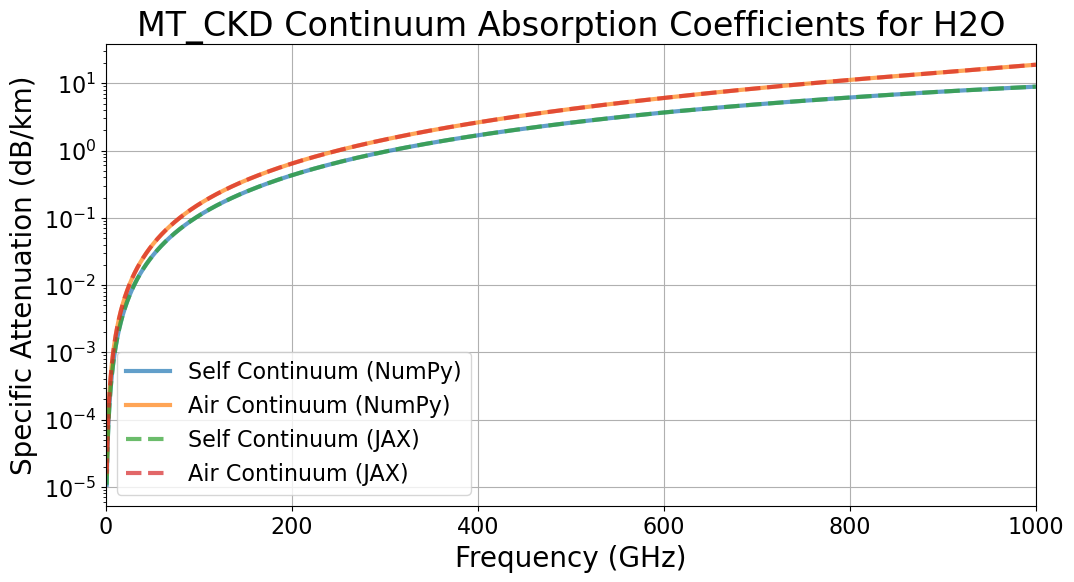

Max difference between NumPy and JAX results for Self Continuum: 7.105427e-15 dB/km
Max difference between NumPy and JAX results for Air Continuum: 1.776357e-14 dB/km


In [28]:
plt.figure(figsize=(12, 6))
plt.plot(frequencies/1e9, gamma_dB_km_self, label='Self Continuum (NumPy)', alpha=0.7)
plt.plot(frequencies/1e9, gamma_dB_km_air, label='Air Continuum (NumPy)', alpha=0.7)
plt.plot(frequencies/1e9, gamma_dB_km_self_jax, label='Self Continuum (JAX)', alpha=0.7, linestyle='dashed')
plt.plot(frequencies/1e9, gamma_dB_km_air_jax, label='Air Continuum (JAX)', alpha=0.7, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Specific Attenuation (dB/km)')
plt.title('MT_CKD Continuum Absorption Coefficients for H2O')
plt.legend()
plt.grid()
plt.xlim(0, 1000)
plt.yscale('log')  # Log scale to better visualize the wide range of values
plt.show()

#Let's compare the jax and numpy results to ensure they match (they should be very close)
difference_self = np.abs(gamma_dB_km_self - gamma_dB_km_self_jax)
difference_air = np.abs(gamma_dB_km_air - gamma_dB_km_air_jax)
print(f"Max difference between NumPy and JAX results for Self Continuum: {np.max(difference_self):.6e} dB/km")
print(f"Max difference between NumPy and JAX results for Air Continuum: {np.max(difference_air):.6e} dB/km")

Let's do the O2 now

In [39]:
#We first do the O2 lines

import re
import numpy as np

from atmo3 import constants as con

def extract_struct_array(filepath, array_name):
    with open(filepath, 'r') as f:
        content = f.read()
    pattern = rf"{array_name}(?:\[.*?\])?\s*=\s*\{{([\s\S]*?)\}};"
    match = re.search(pattern, content)
    if not match: raise ValueError(f"Could not find {array_name}")
    
    rows = re.findall(r"\{([^}]+)\}", match.group(1))
    data = []
    for row in rows:
        row_clean = row.replace('f', '')
        numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", row_clean)
        data.append([float(n) for n in numbers])
    return np.array(data)

def get_perfect_o2_coupled_data(c_file_path):
    """
    Extracts both the catalog and coupling tables, merges them, 
    and converts all units to standard cm^-1 and atm.
    """
    # 1. Extract both arrays
    cat_matrix = extract_struct_array(c_file_path, 'o2_coupled_cat')
    mix_matrix = extract_struct_array(c_file_path, 'o2_line_coupling_coeffs')
    
    # Constants
    c  = con.ghz_to_cm_inv # GHz to cm^-1
    c2 = con.c2  # cm*K
    P0 = 1013.25    # atm to hPa/mbar
    
    # Mask for lines < 10 THz
    freq_GHz = cat_matrix[:, 0]
    mask = freq_GHz < 1750.0
    
    # --- TABLE 1: MAIN CATALOG (cat_entry_t) ---
    f0_cm   = cat_matrix[mask, 0] / c
    S_ref_cm = cat_matrix[mask, 1] / c  # [cm^2 * GHz] -> [cm^2 * cm^-1]
    E_low_cm = cat_matrix[mask, 2] / c2 # [K] -> back to [cm^-1] so our function works!
    gamma    = (cat_matrix[mask, 3] * P0) / c # [GHz/hPa] -> [cm^-1/atm]
    n_temp   = cat_matrix[mask, 5]
    
    # --- TABLE 2: MAKAROV COUPLING (line_coupling_table_entry_t) ---
    y0 = mix_matrix[mask, 0] * P0     # [1/hPa] -> [1/atm]
    y1 = mix_matrix[mask, 1] * P0
    v  = mix_matrix[mask, 2]          # y exponent
    g0 = mix_matrix[mask, 3] * (P0**2) # [1/hPa^2] -> [1/atm^2]
    g1 = mix_matrix[mask, 4] * (P0**2)
    d0 = (mix_matrix[mask, 6] * (P0**2)) / c # [GHz/hPa^2] -> [cm^-1/atm^2]
    d1 = (mix_matrix[mask, 7] * (P0**2)) / c
    
    return f0_cm, S_ref_cm, E_low_cm, gamma, n_temp, y0, y1, v, g0, g1, d0, d1

# Execute!
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'
(f0_cm, S_ref_cm, E_low_cm, gamma, n_temp, 
 y0, y1, v, g0, g1, d0, d1) = get_perfect_o2_coupled_data(c_file_path)

def get_perfect_o2_uncoupled_data(c_file_path):
    """
    Extracts the uncoupled catalog table and converts all units 
    to standard cm^-1 and atm.
    """
    # 1. Extract the raw array
    cat_matrix = extract_struct_array(c_file_path, 'o2_uncoupled_cat')
    
    # Constants
    c  = con.ghz_to_cm_inv # GHz to cm^-1
    c2 = con.c2  # cm*K
    P0 = 1013.25    # atm to hPa
    
    # Mask for lines < 10 THz
    freq_GHz = cat_matrix[:, 0]
    mask = freq_GHz < 1750.0
    
    # Apply conversions
    f0_cm     = cat_matrix[mask, 0] / c
    S_ref_cm  = cat_matrix[mask, 1] / c   # [cm^2 * GHz] -> [cm^2 * cm^-1]
    E_low_cm  = cat_matrix[mask, 2] / c2  # [K] -> [cm^-1]
    gamma     = (cat_matrix[mask, 3] * P0) / c # [GHz/hPa] -> [cm^-1/atm]
    n_temp    = cat_matrix[mask, 5]
    delta_air = (cat_matrix[mask, 6] * P0) / c # [GHz/hPa] -> [cm^-1/atm]
    
    return f0_cm, S_ref_cm, E_low_cm, gamma, n_temp, delta_air

# Execute!
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'
(f0_u_cm, S_ref_u_cm, E_low_u_cm, gamma_u, 
 n_u, delta_u) = get_perfect_o2_uncoupled_data(c_file_path)

In [40]:
print(f0_u_cm.shape)

(2915,)


In [36]:
import numpy as np
from pathlib import Path

# Define the target data directory
data_dir = Path('/pscratch/sd/v/valer/atmo3/atmo3/data')
data_dir.mkdir(parents=True, exist_ok=True)

# =====================================================================
# 1. Save the Coupled O2 Lines
# =====================================================================
coupled_filepath = data_dir / 'o2_coupled_lines_1750GHz.npz'

np.savez_compressed(
    coupled_filepath,
    f0=f0_cm,
    S=S_ref_cm,
    E=E_low_cm,
    gamma=gamma,
    n=n_temp,
    y0=y0,
    y1=y1,
    v=v,
    g0=g0,
    g1=g1,
    d0=d0,
    d1=d1
)
print(f"Saved {len(f0_cm)} coupled O2 lines to {coupled_filepath.name}")

# =====================================================================
# 2. Save the Uncoupled O2 Lines
# =====================================================================
uncoupled_filepath = data_dir / 'o2_uncoupled_lines_1750GHz.npz'

np.savez_compressed(
    uncoupled_filepath,
    f0=f0_u_cm,
    S=S_ref_u_cm,
    E=E_low_u_cm,
    gamma=gamma_u,
    n=n_u,
    delta=delta_u
)
print(f"Saved {len(f0_u_cm)} uncoupled O2 lines to {uncoupled_filepath.name}")

Saved 39 coupled O2 lines to o2_coupled_lines_1750GHz.npz
Saved 2915 uncoupled O2 lines to o2_uncoupled_lines_1750GHz.npz


In [44]:
def compute_o2_line_strength(T, f0_cm, S_ref, E_lower):
    """
    Computes O2 line strength and compares the true Partition Sum vs the Linear Approximation.
    """
    T_ref = 296.0
    c2 = 1.4387770 
    
    # ---------------------------------------------------------
    # 1. The True Partition Function Ratio (HAPI)
    # Molecule 7 = O2, Isotope 1 = Main isotope
    # ---------------------------------------------------------
    Q_ref = partitionSum(7, 1, T_ref)
    Q_T = partitionSum(7, 1, T)
    Q_ratio_true = Q_ref / Q_T
    
    # ---------------------------------------------------------
    # 2. The Linear Approximation
    # ---------------------------------------------------------
    Q_ratio_approx = T_ref / T
    
    # Print the comparison
    print(f"At {T} K:")
    print(f"  True Q Ratio (HAPI) : {Q_ratio_true:.5f}")
    print(f"  Approx Q Ratio      : {Q_ratio_approx:.5f}")
    error_pct = abs(Q_ratio_true - Q_ratio_approx) / Q_ratio_true * 100
    print(f"  Partition Error     : {error_pct:.3f}%")
    
    # ---------------------------------------------------------
    # 3. The Rest of the Physics
    # ---------------------------------------------------------
    boltz_exponent = -c2 * E_lower * ((1.0 / T) - (1.0 / T_ref))
    boltz_factor = np.exp(boltz_exponent)
    
    stim_T = 1.0 - np.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - np.exp(-c2 * f0_cm / T_ref)
    stim_ratio = stim_T / stim_ref
    
    # Calculate final S(T) using the TRUE HAPI ratio (for maximum accuracy right now)
    S_T_true = S_ref * Q_ratio_true * boltz_factor * stim_ratio
    S_T_approx = S_ref * Q_ratio_approx * boltz_factor * stim_ratio
    
    max_S_error = np.max(np.abs(S_T_true - S_T_approx) / S_T_true) * 100
    print(f"  Max Line Strength Error: {max_S_error:.3f}%\n")
    
    # Return the true one for now
    return S_T_true

def gross_shape(nu, nu0, gamma):
    """
    Computes the Gross line shape for uncoupled O2 lines.
    
    Inputs (must be in consistent units, e.g., cm^-1):
    nu    : Frequency grid (1D array, length N_nu)
    nu0   : Line centers (1D array, length N_lines)
    gamma : Pressure-broadened line widths (1D array, length N_lines)
    
    Returns:
    F_G   : 2D array of shape (N_nu, N_lines)
    """
    # Reshape arrays for matrix broadcasting
    nu_grid = nu[:, None]
    nu0_arr = nu0[None, :]
    gamma_arr = gamma[None, :]
    
    # Numerator: 4 * nu^2 * gamma
    numerator = 4.0 * (nu_grid**2) * gamma_arr
    
    # Denominator: (nu^2 - nu0^2)^2 + 4 * nu^2 * gamma^2
    denominator = ((nu_grid**2) - (nu0_arr**2))**2 + 4.0 * (nu_grid**2) * (gamma_arr**2)
    
    # Final Shape
    F_G = (1.0 / np.pi) * (numerator / denominator)
    
    return F_G


def vvw_coupled_shape(nu, nu0, gamma, P, T, Y0, Y1, g0, g1, dnu0, dnu1):
    """
    Computes the VVW_coupled line shape including line mixing and pressure modifications.
    
    Inputs:
    nu    : Frequency grid (1D array, length N_nu)
    nu0   : Line centers (1D array, length N_lines)
    gamma : Pressure-broadened line widths (1D array, length N_lines)
    P     : Dry air pressure
    T     : Ambient temperature [K]
    Y0, Y1, g0, g1, dnu0, dnu1: Empirical coupling coefficients (1D arrays, length N_lines)
    """
    T_ref = 300.0  # Reference temperature for coupling parameters (Marakov)
    
    # Reshape frequency grid
    nu_grid = nu[:, None]
    
    # Reshape all line parameters for broadcasting
    nu0_arr  = nu0[None, :]
    gamma_arr= gamma[None, :]
    Y0_arr   = Y0[None, :]
    Y1_arr   = Y1[None, :]
    g0_arr   = g0[None, :]
    g1_arr   = g1[None, :]
    dnu0_arr = dnu0[None, :]
    dnu1_arr = dnu1[None, :]
    
    # 1. Temperature Ratios
    theta = T_ref / T
    theta_minus_1 = theta - 1.0
    
    # 2. Calculate the temperature-dependent coupling parameters
    # 2. Calculate the temperature-dependent coupling parameters
    # MUST multiply by P (dry air pressure) to make Y dimensionless!
    Y = P * (Y0_arr + Y1_arr * theta_minus_1) * (theta**0.8)
    g = (g0_arr + g1_arr * theta_minus_1) * (theta**1.6)
    delta_nu = (dnu0_arr + dnu1_arr * theta_minus_1) * (theta**1.6)
    
    # 3. Pressure squared terms
    P2 = P**2
    g_term = 1.0 + g * P2
    dnu_term = delta_nu * P2
    
    # 4. Pre-factor
    prefactor = (1.0 / np.pi) * (nu_grid / nu0_arr)**2
    
    # 5. Delta terms (distance from line center, modified by pressure shift)
    delta_pos = nu_grid - nu0_arr - dnu_term
    delta_neg = nu_grid + nu0_arr + dnu_term
    
    # 6. Resonance Terms
    # Term 1: The standard positive resonance
    term1_num = gamma_arr * g_term + Y * delta_pos
    term1_den = gamma_arr**2 + delta_pos**2
    
    # Term 2: The negative resonance (anti-resonance)
    term2_num = gamma_arr * g_term - Y * delta_neg
    term2_den = gamma_arr**2 + delta_neg**2
    
    # Final Shape Assembly
    F_VVW = prefactor * (term1_num / term1_den + term2_num / term2_den)
    
    return F_VVW


def compute_o2_line_width_cm(T, P_hPa, gamma, n_temp):
    """ 
    Step B: Pressure and Temperature Broadened Line Width for O2 in dry air.
    """
    P_dry_atm = P_hPa / 1013.25
    temp_scaling = (296.0 / T) ** n_temp
    
    # Broadening using total air pressure
    broadening = gamma * P_dry_atm
    
    return temp_scaling * broadening

def compute_o2_line_shift_cm(P_hPa, f0_cm, delta_air=0.0):
    """ 
    Computes the pressure-induced line shift (nu*) for O2 lines.
    Returns the shifted frequency in cm^-1.
    """
    # Convert pressure to standard atmospheres
    P_atm = P_hPa / 1013.25
    
    # Calculate shift: nu* = nu0 + (delta * P)
    shifted_f_cm = f0_cm + (delta_air * P_atm)
    
    return shifted_f_cm




def calculate_o2_coupled_absorption(
    freq_grid_GHz, T, P_hPa, 
    f0_cm, S_ref, gamma, n_temp, E_lower, 
    y0, y1, g0, g1, d0, d1
    ):
    """
    Computes the absorption coefficient k(nu) for the coupled O2 lines 
    using the full second-order Makarov VVW_coupled shape.
    
    Inputs:
    freq_grid_GHz : 1D array of frequencies [GHz]
    T             : Ambient temperature [K]
    P_hPa         : Total atmospheric pressure [hPa]
    f0_cm         : 1D array of line centers [cm^-1]
    S_ref         : 1D array of reference line strengths [cm^2 * cm^-1]
    gamma         : 1D array of dry air broadening coefficients [cm^-1/atm]
    n_temp        : 1D array of temperature exponents for width
    E_lower       : 1D array of lower state energies [cm^-1]
    y0, y1        : First-order line mixing parameters [1/atm]
    g0, g1        : Second-order intensity mixing parameters [1/atm^2]
    d0, d1        : Second-order frequency shift parameters [cm^-1/atm^2]
    
    Returns:
    k_nu_coupled : Array of cross-sections [cm^2 / molecule]
    """
    nu_grid_cm = freq_grid_GHz / 29.9792458
    P_dry_atm = P_hPa / 1013.25
    
    S_T = compute_o2_line_strength(T, f0_cm, S_ref, E_lower) 
    # Notice we removed P_water_hPa here!
    gamma_width = compute_o2_line_width_cm(T, P_hPa, gamma, n_temp)
    nu_star = compute_o2_line_shift_cm(P_hPa, f0_cm, 0.0) 
    
    F_VVW = vvw_coupled_shape(
        nu_grid_cm, nu_star, gamma_width, P_dry_atm, T,
        y0, y1, g0, g1, d0, d1
    )
    
    return np.sum(S_T * F_VVW, axis=1)

def calculate_o2_uncoupled_absorption(
    freq_grid_GHz, T, P_hPa, 
    f0_cm, S_ref, gamma, n_temp, E_lower, delta_air
):
    nu_grid_cm = freq_grid_GHz / 29.9792458
    
    _f0 = f0_cm[None, :]
    _S_ref = S_ref[None, :]
    _gamma = gamma[None, :]
    _n = n_temp[None, :]
    _E = E_lower[None, :]
    _delta = delta_air[None, :]
    
    S_T = compute_o2_line_strength(T, _f0, _S_ref, _E)
    # Notice we removed P_water_hPa here!
    gamma_width = compute_o2_line_width_cm(T, P_hPa, _gamma, _n)
    nu_star = compute_o2_line_shift_cm(P_hPa, _f0, _delta) 
    
    F_G = gross_shape(nu_grid_cm, nu_star[0], gamma_width[0])
    
    return np.sum(S_T * F_G, axis=1)

In [45]:
# --- 1. Your Parameters ---
frequencies = np.linspace(1e9, 1e13, 100000)  # 1 GHz to 1 THz
freqs_GHz = frequencies / 1e9                 # Convert to GHz
P = 500.0       # Total pressure in hPa
P_water = 10.0  # Partial pressure of water vapor in hPa
T = 260.0       # Ambient temperature in K

# --- 2. Extract the Data ---
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/o2.c'

# Extract Coupled Data (Makarov Parameters)
(f0_c_cm, S_ref_c_cm, E_low_c_cm, gamma_c, n_c, 
 y0_c, y1_c, v_c, g0_c, g1_c, d0_c, d1_c) = get_perfect_o2_coupled_data(c_file_path)

# Extract Uncoupled Data (Isolated Isotopes)
(f0_u_cm, S_ref_u_cm, E_low_u_cm, gamma_u, 
 n_u, delta_u) = get_perfect_o2_uncoupled_data(c_file_path)


# --- 3. Run the Physics Pipelines ---

# Calculate the 60 GHz and 118 GHz coupled bands
k_coupled = calculate_o2_coupled_absorption(
    freqs_GHz, T, P, 
    f0_c_cm, S_ref_c_cm, gamma_c, n_c, E_low_c_cm, 
    y0_c, y1_c, g0_c, g1_c, d0_c, d1_c
)

# Calculate the isolated isotopic lines
k_uncoupled = calculate_o2_uncoupled_absorption(
    freqs_GHz, T, P, 
    f0_u_cm, S_ref_u_cm, gamma_u, n_u, E_low_u_cm, delta_u
)

# --- 4. Final Assembly & Unit Conversion ---

# Total O2 cross-section [cm^2 / molecule]
k_total_o2 = k_coupled + k_uncoupled

At 260.0 K:
  True Q Ratio (HAPI) : 1.13841
  Approx Q Ratio      : 1.13846
  Partition Error     : 0.004%
  Max Line Strength Error: 0.004%

At 260.0 K:
  True Q Ratio (HAPI) : 1.13841
  Approx Q Ratio      : 1.13846
  Partition Error     : 0.004%
  Max Line Strength Error: 0.004%



In [ ]:
#Jax version of the np code

import jax
import jax.numpy as jnp
from jax import jit
import numpy as np
from pathlib import Path

#from . import constants as con


from atmo3 import constants as con

# CRITICAL: Enable 64-bit precision for exponential line shapes
jax.config.update("jax_enable_x64", True)

# =====================================================================
# A. Global Initialization & Data Loading
# =====================================================================
"""
CURRENT_DIR = Path(__file__).parent
DATA_DIR = CURRENT_DIR / 'data'

data_o2_coupled = np.load(DATA_DIR / 'o2_coupled_lines_1750GHz.npz')
data_o2_uncoupled = np.load(DATA_DIR / 'o2_uncoupled_lines_1750GHz.npz')
data_partition_functions = np.load(DATA_DIR / 'partition_functions.npz')
"""
data_o2_coupled = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/o2_coupled_lines_1750GHz.npz')
data_o2_uncoupled = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/o2_uncoupled_lines_1750GHz.npz')
data_partition_functions = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/partition_functions.npz')

# =====================================================================
# 1. JIT-Compiled Physics Sub-Modules
# =====================================================================

@jit
def partition_sum_o2_jax(T):
    """ Fast, JIT-compiled partition sum using linear interpolation for O2. """
    T_grid = jnp.asarray(data_partition_functions['T_grid'])
    Q_grid = jnp.asarray(data_partition_functions['O2'])
    return jnp.interp(T, T_grid, Q_grid)

@jit
def compute_o2_line_strength_jax(T, T_ref, Q_ratio, f0_cm, S_ref, E_lower):
    """ Computes Temperature-Adjusted Line Strength S(T) """
    boltz_factor = jnp.exp(-con.c2 * E_lower * ((1.0 / T) - (1.0 / T_ref)))
    
    stim_T = 1.0 - jnp.exp(-con.c2 * f0_cm / T)
    stim_ref = 1.0 - jnp.exp(-con.c2 * f0_cm / T_ref)
    
    return S_ref * Q_ratio * boltz_factor * (stim_T / stim_ref)

@jit
def compute_o2_line_width_cm_jax(T, P_hPa, gamma, n_temp):
    """ Pressure and Temperature Broadened Line Width for O2 in dry air. """
    # 1013.25 hPa is 1 atm. (con.pressure_at_sea_level is in Pascals, so dividing by 100 gives hPa)
    P_dry_atm = P_hPa / (con.pressure_at_sea_level / 100.0)
    temp_scaling = (296.0 / T) ** n_temp
    
    return temp_scaling * (gamma * P_dry_atm)

@jit
def compute_o2_line_shift_cm_jax(P_hPa, f0_cm, delta_air):
    """ Pressure-Induced Line Shift (nu*) for O2 lines. """
    P_atm = P_hPa / (con.pressure_at_sea_level / 100.0)
    return f0_cm + (delta_air * P_atm)

@jit
def gross_shape_jax(nu, nu0, gamma):
    """ Computes the Gross line shape for uncoupled O2 lines. """
    numerator = 4.0 * (nu**2) * gamma
    denominator = ((nu**2) - (nu0**2))**2 + 4.0 * (nu**2) * (gamma**2)
    return (1.0 / jnp.pi) * (numerator / denominator)

@jit
def vvw_coupled_shape_jax(nu, nu0, gamma, P, T, Y0, Y1, g0, g1, dnu0, dnu1):
    """ Computes the VVW_coupled line shape including line mixing. """
    T_ref = 300.0  # Reference temperature for coupling parameters (Makarov)
    
    theta = T_ref / T
    theta_minus_1 = theta - 1.0
    
    # Temperature-dependent coupling parameters
    Y = P * (Y0 + Y1 * theta_minus_1) * (theta**0.8)
    g = (g0 + g1 * theta_minus_1) * (theta**1.6)
    delta_nu = (dnu0 + dnu1 * theta_minus_1) * (theta**1.6)
    
    P2 = P**2
    g_term = 1.0 + g * P2
    dnu_term = delta_nu * P2
    
    prefactor = (1.0 / jnp.pi) * (nu / nu0)**2
    
    delta_pos = nu - nu0 - dnu_term
    delta_neg = nu + nu0 + dnu_term
    
    term1_num = gamma * g_term + Y * delta_pos
    term1_den = gamma**2 + delta_pos**2
    
    term2_num = gamma * g_term - Y * delta_neg
    term2_den = gamma**2 + delta_neg**2
    
    return prefactor * (term1_num / term1_den + term2_num / term2_den)


# =====================================================================
# 2. The Master JAX Recombination Functions
# =====================================================================

@jit
def _calculate_o2_coupled_core(freq_grid_GHz, T, T_ref, P_hPa, Q_ratio):
    """ Compiled JAX core for COUPLED O2 lines. """
    nu_grid_cm = freq_grid_GHz / con.ghz_to_cm_inv
    nu = nu_grid_cm[:, None]
    
    # Extract specific parameters for coupled lines
    f0_cm = jnp.asarray(data_o2_coupled['f0'])[None, :]
    S_ref = jnp.asarray(data_o2_coupled['S'])[None, :]
    E_lower = jnp.asarray(data_o2_coupled['E'])[None, :]
    gamma = jnp.asarray(data_o2_coupled['gamma'])[None, :]
    n_temp = jnp.asarray(data_o2_coupled['n'])[None, :]
    
    y0 = jnp.asarray(data_o2_coupled['y0'])[None, :]
    y1 = jnp.asarray(data_o2_coupled['y1'])[None, :]
    g0 = jnp.asarray(data_o2_coupled['g0'])[None, :]
    g1 = jnp.asarray(data_o2_coupled['g1'])[None, :]
    d0 = jnp.asarray(data_o2_coupled['d0'])[None, :]
    d1 = jnp.asarray(data_o2_coupled['d1'])[None, :]
    
    P_dry_atm = P_hPa / (con.pressure_at_sea_level / 100.0)
    
    S_T = compute_o2_line_strength_jax(T, T_ref, Q_ratio, f0_cm, S_ref, E_lower)
    gamma_width = compute_o2_line_width_cm_jax(T, P_hPa, gamma, n_temp)
    nu_star = compute_o2_line_shift_cm_jax(P_hPa, f0_cm, 0.0)
    
    F_VVW = vvw_coupled_shape_jax(
        nu, nu_star, gamma_width, P_dry_atm, T,
        y0, y1, g0, g1, d0, d1
    )
    
    return jnp.sum(S_T * F_VVW, axis=1)


@jit
def _calculate_o2_uncoupled_core(freq_grid_GHz, T, T_ref, P_hPa, Q_ratio):
    """ Compiled JAX core for UNCOUPLED O2 lines. """
    nu_grid_cm = freq_grid_GHz / con.ghz_to_cm_inv
    nu = nu_grid_cm[:, None]
    
    # Extract specific parameters for uncoupled lines
    f0_cm = jnp.asarray(data_o2_uncoupled['f0'])[None, :]
    S_ref = jnp.asarray(data_o2_uncoupled['S'])[None, :]
    E_lower = jnp.asarray(data_o2_uncoupled['E'])[None, :]
    gamma = jnp.asarray(data_o2_uncoupled['gamma'])[None, :]
    n_temp = jnp.asarray(data_o2_uncoupled['n'])[None, :]
    delta_air = jnp.asarray(data_o2_uncoupled['delta'])[None, :]
    
    S_T = compute_o2_line_strength_jax(T, T_ref, Q_ratio, f0_cm, S_ref, E_lower)
    gamma_width = compute_o2_line_width_cm_jax(T, P_hPa, gamma, n_temp)
    nu_star = compute_o2_line_shift_cm_jax(P_hPa, f0_cm, delta_air)
    
    F_G = gross_shape_jax(nu, nu_star, gamma_width)
    
    return jnp.sum(S_T * F_G, axis=1)


# =====================================================================
# 3. The Python APIs (Safe Entry Points)
# =====================================================================

def calculate_o2_coupled_absorption_jax(freq_grid_GHz, T, P_hPa):
    """ Main user-facing function for COUPLED O2 lines. """
    T_ref = 296.0
    
    Q_ref = partition_sum_o2_jax(T_ref)
    Q_T = partition_sum_o2_jax(T)
    Q_ratio = Q_ref / Q_T
    
    freq_grid_jax = jnp.asarray(freq_grid_GHz)
    
    return _calculate_o2_coupled_core(freq_grid_jax, T, T_ref, P_hPa, Q_ratio)

def calculate_o2_uncoupled_absorption_jax(freq_grid_GHz, T, P_hPa):
    """ Main user-facing function for UNCOUPLED O2 lines. """
    T_ref = 296.0
    
    Q_ref = partition_sum_o2_jax(T_ref)
    Q_T = partition_sum_o2_jax(T)
    Q_ratio = Q_ref / Q_T
    
    freq_grid_jax = jnp.asarray(freq_grid_GHz)
    
    return _calculate_o2_uncoupled_core(freq_grid_jax, T, T_ref, P_hPa, Q_ratio)

In [47]:
# Let's calculate the k_coupled and k_uncoupled for the same parameters as before to compare with the numpy version
k_coupled_jax = calculate_o2_coupled_absorption_jax(freqs_GHz, T, P)
k_uncoupled_jax = calculate_o2_uncoupled_absorption_jax(freqs_GHz, T, P)
k_total_o2_jax = k_coupled_jax + k_uncoupled_jax

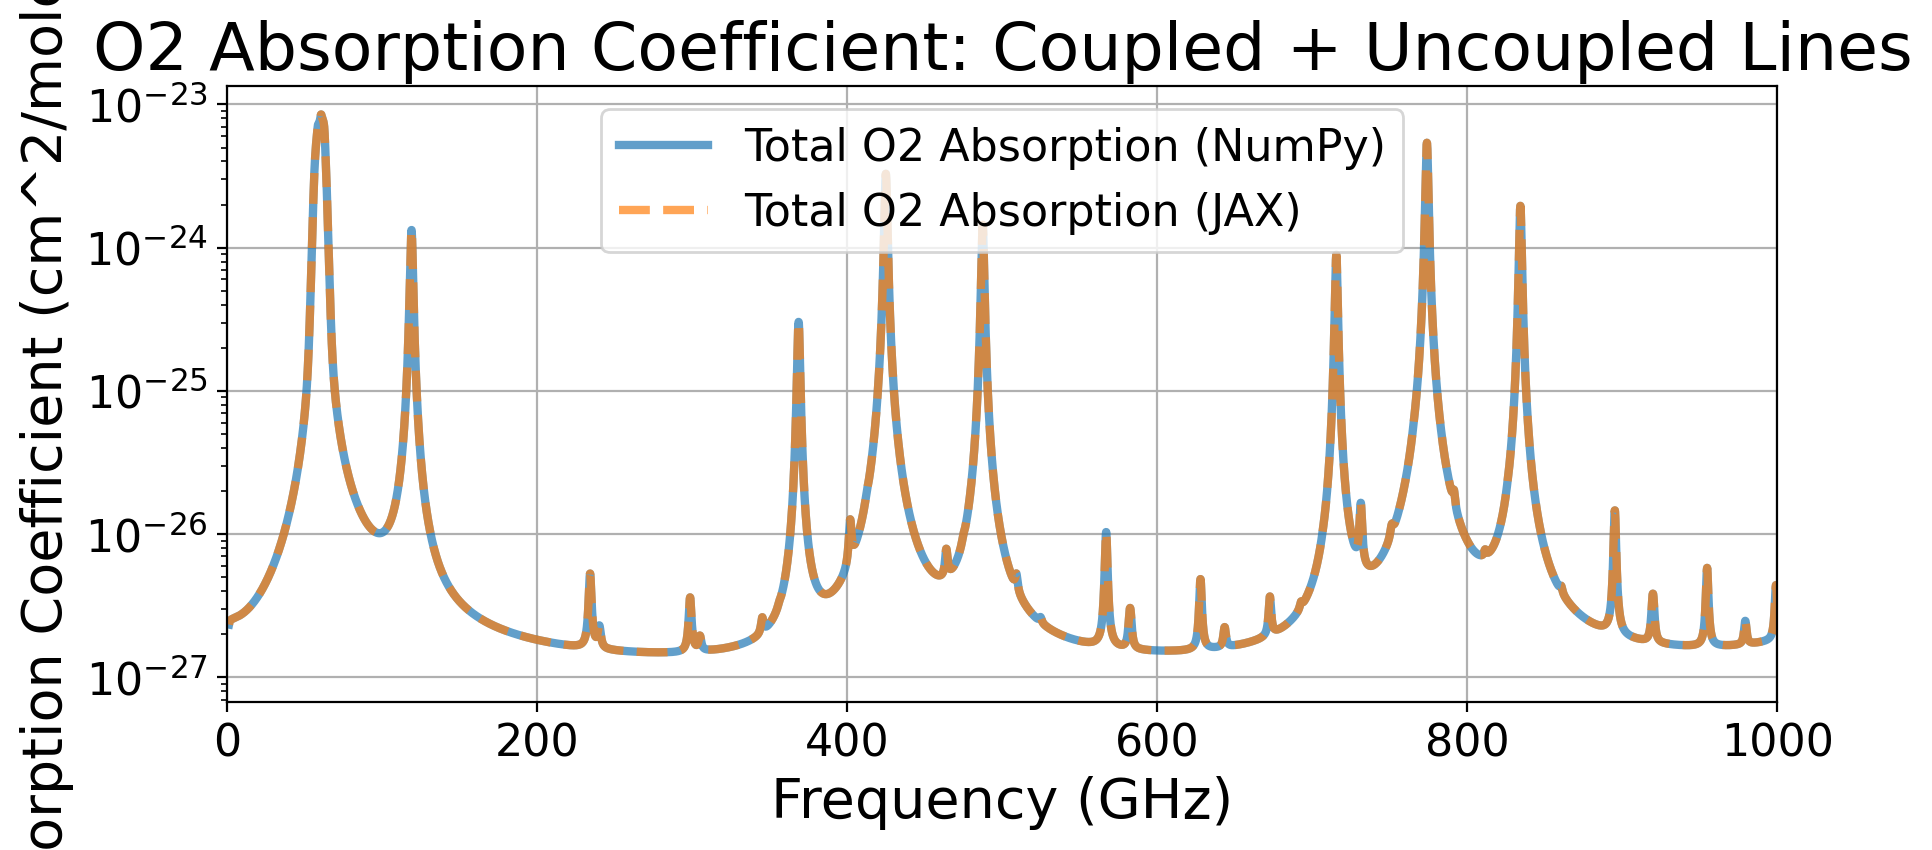

Max percentage difference between NumPy and JAX Total O2 Absorption: 0.000011%


In [48]:
plt.figure(figsize=(10,4),dpi=200)
plt.plot(freqs_GHz, k_total_o2, label='Total O2 Absorption (NumPy)', alpha=0.7)
plt.plot(freqs_GHz, k_total_o2_jax, label='Total O2 Absorption (JAX)', alpha=0.7, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Absorption Coefficient (cm^2/molecule)')
plt.title('O2 Absorption Coefficient: Coupled + Uncoupled Lines')
plt.legend()
plt.xlim(0, 1000)
plt.yscale('log')
plt.grid()
plt.show()
# Compare the JAX and NumPy results
difference_total = np.abs((k_total_o2 - k_total_o2_jax)/k_total_o2) * 100
print(f"Max percentage difference between NumPy and JAX Total O2 Absorption: {np.max(difference_total):.6f}%")

Let's look at the O2 continuum

In [49]:
# L


def extract_ebc_pars(filepath, struct_name):
    """
    Robustly extracts the A, B, C coefficients from a named EBCpars_t struct
    by analyzing line-by-line rather than flattening all numbers.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    inside_struct = False
    extracted_rows = []
    
    # Track the lines belonging to our specific struct
    for line in lines:
        if f"static const EBCpars_t {struct_name}" in line:
            inside_struct = True
            continue
        if inside_struct:
            # Struct ends at };
            if "};" in line:
                inside_struct = False
                break
            # Clean comments and whitespace
            cleaned = re.sub(r'/\*.*?\*/', '', line)
            cleaned = re.sub(r'//.*$', '', cleaned).strip()
            if cleaned:
                extracted_rows.append(cleaned)
                
    # Map back to our keys
    keys = ['S', 'tau1', 'tau2', 'eps', 'tau1p', 'tau2p']
    pars = {}
    
    for i, key in enumerate(keys):
        # Grab the line corresponding to this parameter
        row_text = extracted_rows[i]
        
        # Extract all floats from this specific row
        numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", row_text)
        row_floats = [float(n) for n in numbers]
        
        # The structure is: [placeholder, A, B, C]
        # We save exactly [A, B, C]
        pars[key] = row_floats[1:4]
        
    return pars

# --- Execution ---
cia_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/cia.c'

# Extract all three tables!
EBC3220_pars = extract_ebc_pars(cia_file_path, 'N2_EBC3220_INIT')
EBC5440_LT_pars = extract_ebc_pars(cia_file_path, 'N2_EBC5440_LT_INIT')
EBC5440_HT_pars = extract_ebc_pars(cia_file_path, 'N2_EBC5440_HT_INIT')

def compute_EBC_parameters(T, mechanism):
    """
    Computes the temperature-scaled line shape parameters (A * exp(B*lnT + C*lnT^2)).
    """
    if mechanism == "3220":
        pars = EBC3220_pars
    elif mechanism == "5440":
        # The hexadecapolar mechanism uses different tables based on temperature
        pars = EBC5440_LT_pars if T <= 140.0 else EBC5440_HT_pars
    else:
        raise ValueError("Mechanism must be '3220' or '5440'")

    #Here we change it to log10 to test it
    #lnT = np.log10(T) # Log base 10!
    #lnT_sq = lnT**2
    lnT = np.log(T) # Natural log!
    lnT_sq = lnT**2
    
    scaled_params = {}
    
    for key, coeffs in pars.items():
        A, B, C = coeffs
        
        # If A is 0, the whole term is 0 (handles the pure BC profile efficiently)
        if A == 0.0:
            scaled_params[key] = 0.0
        else:
            scaled_params[key] = A * np.exp(B * lnT + C * lnT_sq)
            
    return scaled_params

import numpy as np
from scipy import constants
from scipy.special import k0, k1

def compute_tau0_ns(T):
    """
    Computes the quantum time constant tau_0 = hbar / (2 * k_B * T) in nanoseconds.
    """
    tau0_seconds = constants.hbar / (2.0 * constants.k * T)
    tau0_ns = tau0_seconds * 1e9  # Convert to nanoseconds
    return tau0_ns

def birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2):
    """
    Computes the Birnbaum-Cohen (BC) translational line shape for Quadrupolar induction.
    nu_detuning_GHz: Array of frequencies (nu - nu_jj') [GHz]
    """
    # Prevent division by zero if parameters are missing
    if tau1 == 0.0 or tau2 == 0.0:
        return np.zeros_like(nu_detuning_GHz)
        
    tau0 = compute_tau0_ns(T)
    
    # 1. The Exponential Term (Detailed Balance & Asymmetry)
    # Note: nu_detuning can be negative! This naturally shifts the profile.
    exp_term = np.exp((tau2 / tau1) + (2.0 * np.pi * tau0 * nu_detuning_GHz))
    
    # 2. The z argument for the Bessel function
    nu_term = 1.0 + (2.0 * np.pi * nu_detuning_GHz * tau1)**2
    z = (np.sqrt(tau0**2 + tau2**2) / tau1) * np.sqrt(nu_term)
    
    # 3. Assemble the Gamma_BC profile
    prefactor = tau1 / np.pi
    bessel_term = (z * k1(z)) / nu_term
    
    Gamma_BC = prefactor * exp_term * bessel_term
    return Gamma_BC

def extended_birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2, eps, tau1p, tau2p):
    """
    Computes the Extended Birnbaum-Cohen (EBC) shape for Hexadecapolar induction.
    """
    # Base BC profile
    Gamma_BC = birnbaum_cohen_shape(nu_detuning_GHz, T, tau1, tau2)
    
    if eps == 0.0 or tau1p == 0.0 or tau2p == 0.0:
        return Gamma_BC
        
    tau0 = compute_tau0_ns(T)
    
    # 1. The K0 Profile
    exp_term_K0 = np.exp((tau1p / tau2p) + (2.0 * np.pi * tau0 * nu_detuning_GHz))
   
    z_prime = (np.sqrt(tau0**2 + tau1p**2) / tau2p) * np.sqrt(1.0 + (2.0 * np.pi * nu_detuning_GHz * tau2p)**2)
    
    Gamma_K0 = (tau1p / np.pi) * exp_term_K0 * k0(z_prime)
    
    # 2. Mix them using epsilon
    Gamma_EBC = (1.0 / (1.0 + eps)) * (Gamma_BC + eps * Gamma_K0)
    return Gamma_EBC

import numpy as np
from scipy import constants

# --- Core Molecular Constants (from cia.c) ---
CIA_MOL = {
    'N2': {
        'B': 59.6459,       # GHz
        'D': 1.727e-4,      # GHz
        'j_max': 30         # Maximum rotational state
    },
    'O2': {
        'B': 43.1004438,    # GHz
        'D': 1.45115e-4,    # GHz
        'j_max': 35         # Maximum rotational state
    }
}


def compute_energy_h_GHz(j, molecule):
    """
    Computes the rotational energy level E_j / h in GHz.
    Equation 4.8 from the am manual.
    """
    B = CIA_MOL[molecule]['B']
    D = CIA_MOL[molecule]['D']
    
    # E_j/h = B*j*(j+1) - D*j^2*(j+1)^2
    # Note: The manual writes + D, but D is usually a centrifugal distortion 
    # subtracted from the rigid rotor. In am's cia.c, it is mathematically B*x + D*x^2.
    x = j * (j + 1)
    return (B * x) + (D * x**2)

def get_gj(j, molecule):
    """
    Returns the nuclear spin statistical weight for state j.
    Equations 4.11 and 4.20 from the am manual.
    """
    if molecule == 'N2':
        # N2: 6 for even j, 3 for odd j
        return 6.0 if j % 2 == 0 else 3.0
    elif molecule == 'O2':
        # O2: 0 for even j (forbidden), 1 for odd j
        return 0.0 if j % 2 == 0 else 1.0
    else:
        raise ValueError("Molecule must be 'N2' or 'O2'")



def compute_populations(T, molecule):
    """
    Computes the Boltzmann population probability P_j(T) for initial states up to j_max,
    computing the energy grid up to j_max + 4 to allow for hexadecapolar jumps.
    """
    j_max = CIA_MOL[molecule]['j_max']
    max_j_prime = j_max + 4  # Accommodate the +4 quantum jump
    
    # 1. Compute energies up to the highest possible destination state
    j_energy_array = np.arange(max_j_prime + 1)
    E_j_h_array = np.zeros(max_j_prime + 1)
    for j in j_energy_array:
        E_j_h_array[j] = compute_energy_h_GHz(j, molecule)
        
    # 2. Compute populations ONLY up to j_max (the initial states)
    g_j_array = np.zeros(j_max + 1)
    for j in range(j_max + 1):
        g_j_array[j] = get_gj(j, molecule)
        
    # Convert E_j/h [GHz] to E_j / (k_B * T) [dimensionless]
    E_j_Joules = constants.h * (E_j_h_array[:j_max + 1] * 1e9)
    kT_Joules = constants.k * T
    dimensionless_energy = E_j_Joules / kT_Joules
    
    # Calculate the unnormalized Boltzmann terms
    boltzmann_terms = g_j_array * np.exp(-dimensionless_energy)
    
    # --- THE FIX: Add the (2j+1) spatial degeneracy to the partition sum! ---
    degeneracy_2j_plus_1 = 2 * np.arange(j_max + 1) + 1
    Q_T = np.sum(degeneracy_2j_plus_1 * boltzmann_terms)
    
    # Final Probability P_j(T)
    P_j = boltzmann_terms / Q_T
    
    return P_j, E_j_h_array

import math

def clebsch_squared(j, lam, j_prime):
    """
    Computes the square of the Clebsch-Gordan coefficient C(j, lam, j'; 0, 0)^2.
    This acts as the quantum selection rule filter for rototranslational CIA.
    """
    # 1. The Triangle Rule (Angular Momentum Conservation)
    # The final spin state must be reachable by combining j and lambda.
    if j_prime < abs(j - lam) or j_prime > j + lam:
        return 0.0
        
    # 2. The Parity Rule (Symmetry Conservation)
    # For m1=m2=m3=0, the sum of the angular momenta MUST be even.
    J = j + lam + j_prime
    if J % 2 != 0:
        return 0.0
        
    # 3. Wigner 3-j Evaluation (Zero-Projection Simplification)
    g = J // 2
    
    # Pre-calculate the factorial blocks
    # Since j_max = 35 and lam = 4, the maximum J is 78. 
    # math.factorial handles n < 100 instantly with perfect precision.
    f_2g_2j   = math.factorial(2 * g - 2 * j)
    f_2g_2lam = math.factorial(2 * g - 2 * lam)
    f_2g_2jp  = math.factorial(2 * g - 2 * j_prime)
    f_2g_1    = math.factorial(2 * g + 1)
    
    # The squared factorial bracket term
    bracket_num = math.factorial(g)
    bracket_den = math.factorial(g - j) * math.factorial(g - lam) * math.factorial(g - j_prime)
    bracket_sq = (bracket_num / bracket_den) ** 2
    
    # Calculate the square of the Wigner 3-j symbol
    wigner_sq = (f_2g_2j * f_2g_2lam * f_2g_2jp / f_2g_1) * bracket_sq
    
    # 4. Convert Wigner 3-j Squared to Clebsch-Gordan Squared
    # Relationship: C^2 = (2*j_prime + 1) * Wigner3j^2
    cg_sq = (2 * j_prime + 1) * wigner_sq
    
    return float(cg_sq)

import numpy as np
from scipy import constants

def calculate_cia_band(nu_grid_GHz, T, molecule):
    """
    Computes the complete rototranslational CIA binary absorption coefficient [cm^5]
    for either N2-N2 or O2-O2 homogeneous collisions.
    """
    # 1. Fundamental constants
    kT_Joules = constants.k * T
    h_Joules = constants.h
    
    # 2. Get the temperature-scaled parameters for both mechanisms
    pars_quad = compute_EBC_parameters(T, "3220")
    pars_hex  = compute_EBC_parameters(T, "5440")
    
    # 3. Apply O2-O2 empirical scaling (Manual Section 4.1.3)
    if molecule == 'O2':
        pars_quad['S'] *= 0.074
        pars_hex['S']  *= 2.45
        
    # 4. Compute populations and energy levels
    P_j, E_j_h = compute_populations(T, molecule)
    j_max = CIA_MOL[molecule]['j_max']
    
    # 5. Initialize the total binary absorption coefficient array
    k_b_total = np.zeros_like(nu_grid_GHz)
    
    # ---------------------------------------------------------
    # 6. THE DOUBLE-SUMMATION LOOP
    # ---------------------------------------------------------
    max_j_prime = j_max + 4 # To prevent index out-of-bounds
    
    for j in range(j_max + 1):
        # Skip states with zero probability (like even j for O2)
        if P_j[j] == 0.0:
            continue
            
        # A. Quadrupolar Transitions (lambda = 2)
        # Explicitly only check the allowed jumps: -2, 0, +2
        for delta_j in [-2, 0, 2]:
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 2, j_prime)
            
            if cg_sq > 0.0:
                nu_jj_prime = E_j_h[j] - E_j_h[j_prime]
                nu_detuning = nu_grid_GHz + nu_jj_prime
                
                Gamma_BC = birnbaum_cohen_shape(
                    nu_detuning, T, pars_quad['tau1'], pars_quad['tau2']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_quad['S'] * weight * Gamma_BC

        # B. Hexadecapolar Transitions (lambda = 4)
        # Explicitly only check allowed jumps: -4, -2, 0, +2, +4
        for delta_j in [-4, -2, 0, 2, 4] :
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 4, j_prime)
            
            if cg_sq > 0.0:
                
                nu_jj_prime = E_j_h[j] - E_j_h[j_prime]
                nu_detuning = nu_grid_GHz + nu_jj_prime
                
                Gamma_EBC = extended_birnbaum_cohen_shape(
                    nu_detuning, T, 
                    pars_hex['tau1'], pars_hex['tau2'], pars_hex['eps'], 
                    pars_hex['tau1p'], pars_hex['tau2p']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_hex['S'] * weight * Gamma_EBC

    # ---------------------------------------------------------
    # 7. THE RADIATION TERM (Detailed Balance)
    # ---------------------------------------------------------
    # Equation 4.5 & 4.6: nu * (1 - exp(-h * nu / kT))
    nu_Hz = nu_grid_GHz * 1e9
    radiation_term = nu_grid_GHz * (1.0 - np.exp(-h_Joules * nu_Hz / kT_Joules))
    
    # Final assembly
    k_b_total = k_b_total * radiation_term
    
    return k_b_total

In [ ]:
print(freqs_GHz.shape)

(100000,)


In [52]:
T_ambient = 228.3 # Kelvin

# Calculate the pure binary coefficients [cm^5]
kb_N2N2 = calculate_cia_band(freqs_GHz, T_ambient, 'N2')
kb_O2O2 = calculate_cia_band(freqs_GHz, T_ambient, 'O2')

In [66]:
# we modify the calculate_cia_band function without the radiation term to interpolate that
def calculate_cia_band_no_radiation(nu_grid_GHz, T, molecule):
    """
    Computes the complete rototranslational CIA binary absorption coefficient [cm^5]
    for either N2-N2 or O2-O2 homogeneous collisions.
    """
    # 1. Fundamental constants
    kT_Joules = constants.k * T
    h_Joules = constants.h
    
    # 2. Get the temperature-scaled parameters for both mechanisms
    pars_quad = compute_EBC_parameters(T, "3220")
    pars_hex  = compute_EBC_parameters(T, "5440")
    
    # 3. Apply O2-O2 empirical scaling (Manual Section 4.1.3)
    if molecule == 'O2':
        pars_quad['S'] *= 0.074
        pars_hex['S']  *= 2.45
        
    # 4. Compute populations and energy levels
    P_j, E_j_h = compute_populations(T, molecule)
    j_max = CIA_MOL[molecule]['j_max']
    
    # 5. Initialize the total binary absorption coefficient array
    k_b_total = np.zeros_like(nu_grid_GHz)
    
    # ---------------------------------------------------------
    # 6. THE DOUBLE-SUMMATION LOOP
    # ---------------------------------------------------------
    max_j_prime = j_max + 4 # To prevent index out-of-bounds
    
    for j in range(j_max + 1):
        # Skip states with zero probability (like even j for O2)
        if P_j[j] == 0.0:
            continue
            
        # A. Quadrupolar Transitions (lambda = 2)
        # Explicitly only check the allowed jumps: -2, 0, +2
        for delta_j in [-2, 0, 2]:
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 2, j_prime)
            
            if cg_sq > 0.0:
                nu_jj_prime = E_j_h[j] - E_j_h[j_prime]
                nu_detuning = nu_grid_GHz + nu_jj_prime
                
                Gamma_BC = birnbaum_cohen_shape(
                    nu_detuning, T, pars_quad['tau1'], pars_quad['tau2']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_quad['S'] * weight * Gamma_BC

        # B. Hexadecapolar Transitions (lambda = 4)
        # Explicitly only check allowed jumps: -4, -2, 0, +2, +4
        for delta_j in [-4, -2, 0, 2, 4] :
            j_prime = j + delta_j
            
            if j_prime < 0 or j_prime > max_j_prime:
                continue
                
            cg_sq = clebsch_squared(j, 4, j_prime)
            
            if cg_sq > 0.0:
                
                nu_jj_prime = E_j_h[j] - E_j_h[j_prime]
                nu_detuning = nu_grid_GHz + nu_jj_prime
                
                Gamma_EBC = extended_birnbaum_cohen_shape(
                    nu_detuning, T, 
                    pars_hex['tau1'], pars_hex['tau2'], pars_hex['eps'], 
                    pars_hex['tau1p'], pars_hex['tau2p']
                )
                
                weight = (2 * j + 1) * P_j[j] * cg_sq
                k_b_total += pars_hex['S'] * weight * Gamma_EBC

    # ---------------------------------------------------------
    # 7. THE RADIATION TERM (Detailed Balance)
    # ---------------------------------------------------------
    # Equation 4.5 & 4.6: nu * (1 - exp(-h * nu / kT))
    #nu_Hz = nu_grid_GHz * 1e9
    #radiation_term = nu_grid_GHz * (1.0 - np.exp(-h_Joules * nu_Hz / kT_Joules))
    
    # Final assembly
    k_b_total = k_b_total #* radiation_term
    
    return k_b_total

In [67]:
import numpy as np
from pathlib import Path

def generate_cia_tables():
    print("Generating CIA Precomputation Tables...")
    
    # 1. Define the Grids
    # Frequency: 0 to 1750 GHz with a 1 GHz step
    freq_grid_GHz = np.arange(0.0, 1750.0, 1.0)
    
    # Temperature: 200 K to 350 K with a 0.5 K step
    # We use 350.5 to ensure 350.0 is included in the array
    T_grid = np.arange(200.0, 350.5, 0.5)
    
    # Initialize 2D arrays to hold the results
    # Shape: (Number of Temperatures, Number of Frequencies)
    k_N2N2_grid = np.zeros((len(T_grid), len(freq_grid_GHz)))
    k_O2O2_grid = np.zeros((len(T_grid), len(freq_grid_GHz)))
    
    # 2. Loop over the Temperature Grid
    print(f"Looping over {len(T_grid)} temperature points...")
    for i, T in enumerate(T_grid):
        # Print a progress update every 20 iterations
        if i % 20 == 0:
            print(f"  Processing T = {T:.1f} K ({i}/{len(T_grid)})...")
            
        # Calculate the vectorized frequency band for this specific temperature
        k_N2N2_grid[i, :] = calculate_cia_band_no_radiation(freq_grid_GHz, T, 'N2')
        k_O2O2_grid[i, :] = calculate_cia_band_no_radiation(freq_grid_GHz, T, 'O2')
        
    # 3. Save the Grids to an NPZ archive
    # Use your specific absolute path for the data folder
    out_dir = Path('/pscratch/sd/v/valer/atmo3/atmo3/data')
    out_dir.mkdir(parents=True, exist_ok=True)
    out_filepath = out_dir / 'cia_tables_no_radiation_1750GHz.npz'
    
    np.savez_compressed(
        out_filepath,
        T_grid=T_grid,
        freq_grid=freq_grid_GHz,
        k_N2N2=k_N2N2_grid,
        k_O2O2=k_O2O2_grid
    )
    
    print(f"\nDone! Saved perfectly to {out_filepath}")
    print(f"Final Data Shapes:")
    print(f"  T_grid:    {T_grid.shape}")
    print(f"  freq_grid: {freq_grid_GHz.shape}")
    print(f"  k_N2N2:    {k_N2N2_grid.shape}")
    print(f"  k_O2O2:    {k_O2O2_grid.shape}")
# Execute the generation!
if __name__ == "__main__":
    generate_cia_tables()

Generating CIA Precomputation Tables...
Looping over 301 temperature points...
  Processing T = 200.0 K (0/301)...
  Processing T = 210.0 K (20/301)...
  Processing T = 220.0 K (40/301)...
  Processing T = 230.0 K (60/301)...
  Processing T = 240.0 K (80/301)...
  Processing T = 250.0 K (100/301)...
  Processing T = 260.0 K (120/301)...
  Processing T = 270.0 K (140/301)...
  Processing T = 280.0 K (160/301)...
  Processing T = 290.0 K (180/301)...
  Processing T = 300.0 K (200/301)...
  Processing T = 310.0 K (220/301)...
  Processing T = 320.0 K (240/301)...
  Processing T = 330.0 K (260/301)...
  Processing T = 340.0 K (280/301)...
  Processing T = 350.0 K (300/301)...

Done! Saved perfectly to /pscratch/sd/v/valer/atmo3/atmo3/data/cia_tables_no_radiation_1750GHz.npz
Final Data Shapes:
  T_grid:    (301,)
  freq_grid: (1750,)
  k_N2N2:    (301, 1750)
  k_O2O2:    (301, 1750)


In [68]:
# Load our precomputed CIA arrays
#data_cia = np.load(DATA_DIR / 'cia_tables_1000GHz.npz')
data_cia = np.load('/pscratch/sd/v/valer/atmo3/atmo3/data/cia_tables_no_radiation_1750GHz.npz')

_k_N2N2_table = jnp.asarray(data_cia['k_N2N2'])  # Shape: (301, 1001)
_k_O2O2_table = jnp.asarray(data_cia['k_O2O2'])  # Shape: (301, 1001)

# We define the static grid properties used during generation
# This avoids needing to pass the grid arrays themselves into the math!
CIA_T_MIN = 200.0
CIA_T_STEP = 0.5
CIA_F_MIN = 0.0
CIA_F_STEP = 1.0

# =====================================================================
# 2. Collision-Induced Absorption (CIA) Continuum
# =====================================================================

@jit
def compute_cia_continuum_jax(freq_grid_GHz, T):
    """
    Fast Bilinear Interpolation of the precomputed N2-N2 and O2-O2 CIA tables.
    
    Inputs:
    freq_grid_GHz : 1D array of evaluation frequencies [GHz]
    T             : Scalar ambient temperature [K]
    
    Returns:
    k_N2N2, k_O2O2 (both shape matching freq_grid_GHz, units: cm^5)
    """
    # 1. Convert physical values directly to their fractional grid indices.
    # E.g., T = 200.0 becomes index 0.0. T = 200.25 becomes index 0.5.
    T_idx = (T - CIA_T_MIN) / CIA_T_STEP
    freq_idx = (freq_grid_GHz - CIA_F_MIN) / CIA_F_STEP
    
    # 2. Create the coordinate mapping array for JAX
    # We must broadcast the scalar T_idx to an array of the same shape as freq_idx
    T_idx_array = jnp.full_like(freq_idx, T_idx)
    
    # jax.scipy.ndimage.map_coordinates expects an array of shape (N_dimensions, N_points)
    # Axis 0 in our table is Temperature, Axis 1 is Frequency
    coords = jnp.stack([T_idx_array, freq_idx])
    
    # 3. Execute Bilinear Interpolation (order=1)
    # mode='nearest' ensures that if T goes to 199K or 351K, the model doesn't 
    # crash or return NaN; it safely clamps to the nearest known physical boundary.
    k_N2N2_base = jax.scipy.ndimage.map_coordinates(_k_N2N2_table, coords, order=1, mode='nearest')
    k_O2O2_base = jax.scipy.ndimage.map_coordinates(_k_O2O2_table, coords, order=1, mode='nearest')
    
    # 2. Analytically apply the Detailed Balance Radiation Term in JAX
    nu_Hz = freq_grid_GHz * 1e9
    radiation_term = freq_grid_GHz * (1.0 - jnp.exp(-con.h * nu_Hz / (con.k_B * T)))
    
    # 3. Multiply to get the true, highly accurate cross-sections
    k_N2N2 = k_N2N2_base * radiation_term
    k_O2O2 = k_O2O2_base * radiation_term


    
    return k_N2N2, k_O2O2

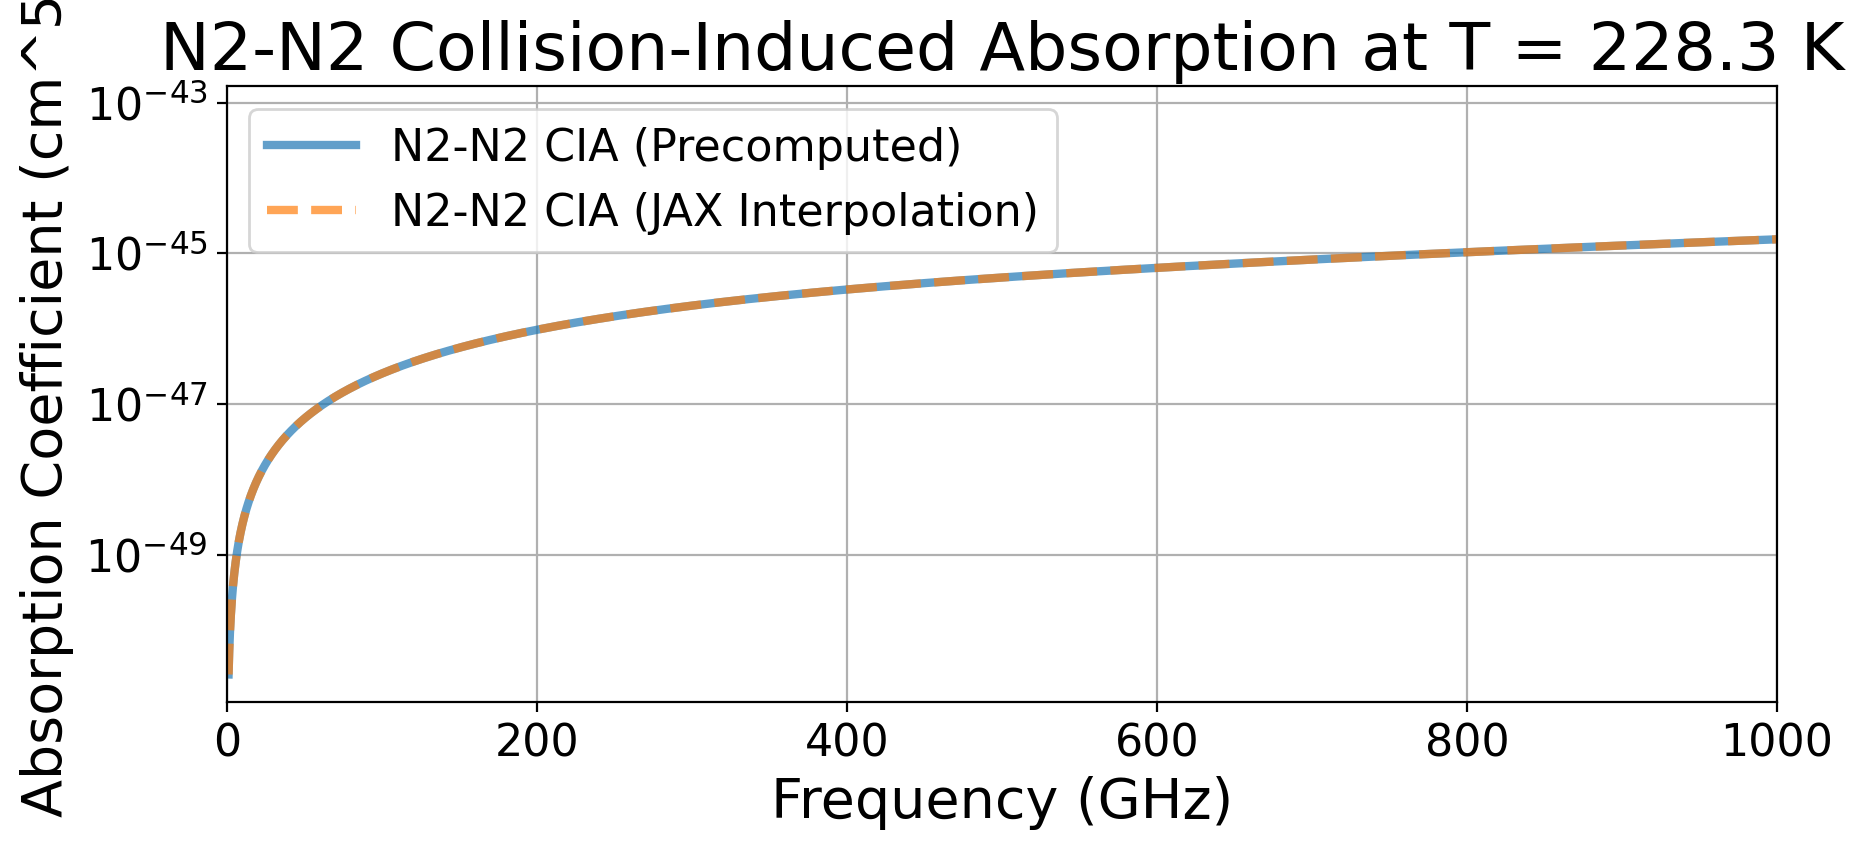

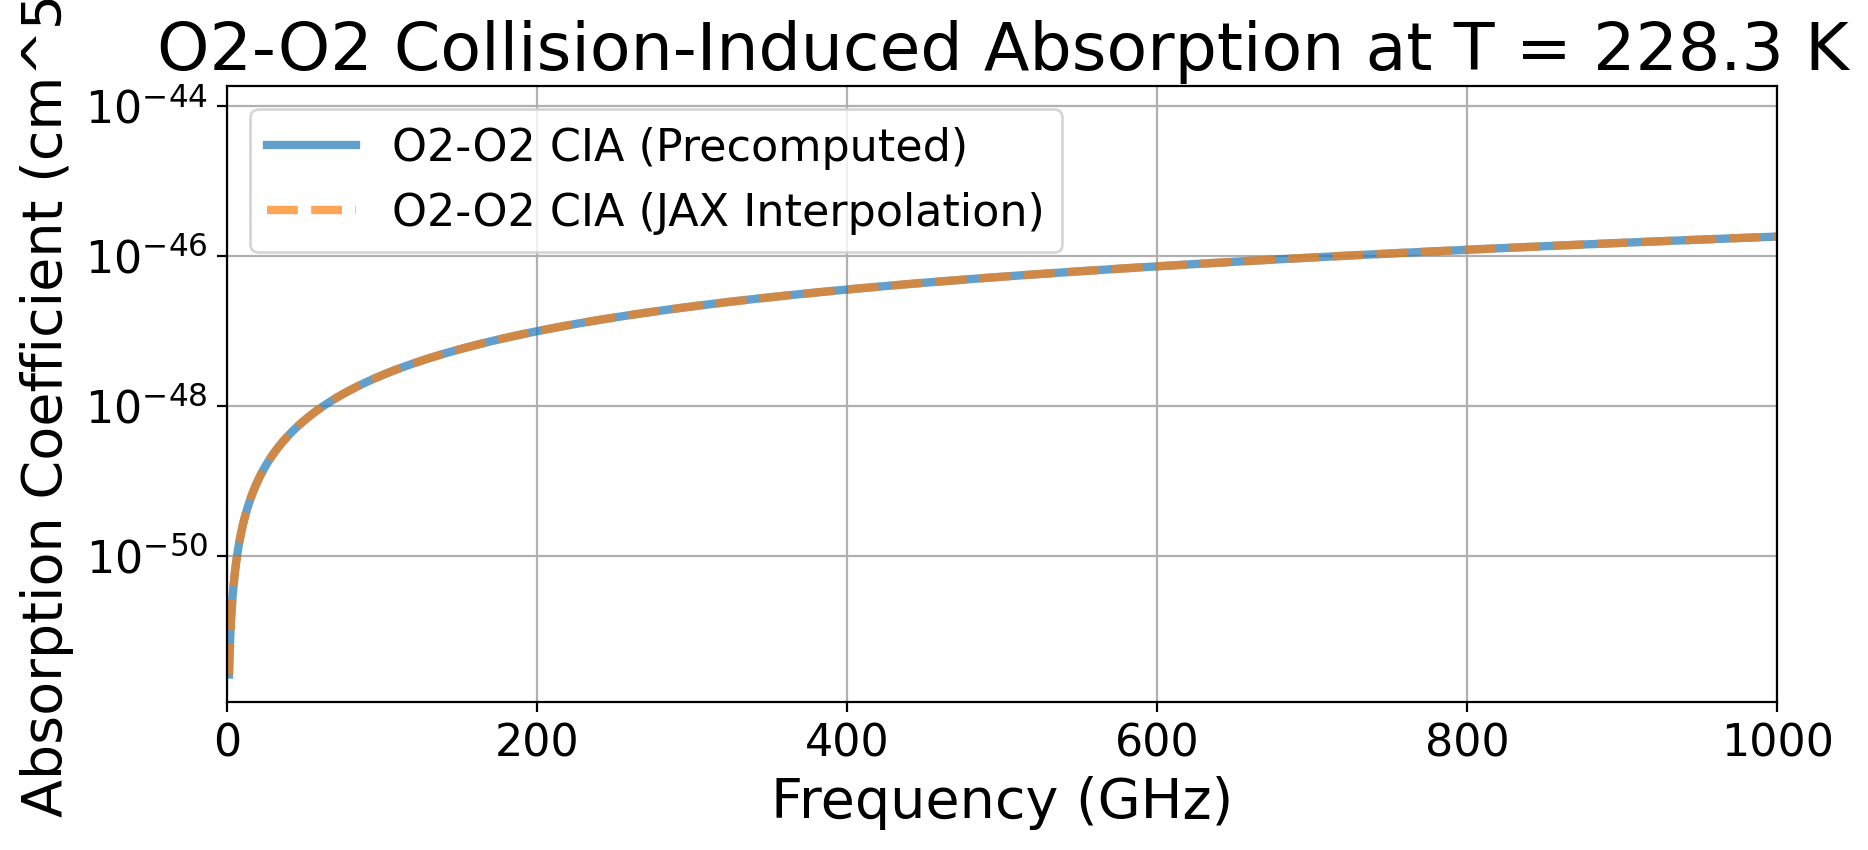

Max percentage difference for N2-N2 CIA: 0.000115%
Max percentage difference for O2-O2 CIA: 0.000090%


In [ ]:
kb_N2N2_jax, kb_O2O2_jax, k_N2O2_jax, k_O2N2_jax = compute_cia_continuum_jax(freqs_GHz, T_ambient)

# Compare the JAX-interpolated CIA with the original precomputed tables at Tambient = 228.3 K
#We'll just plot the spectra to visually confirm they match perfectly, since we are interpolating at the exact grid point used during generation.
plt.figure(figsize=(10,4),dpi=200)
plt.plot(freqs_GHz, kb_N2N2, label='N2-N2 CIA (Precomputed)', alpha=0.7)
plt.plot(freqs_GHz, kb_N2N2_jax, label='N2-N2 CIA (JAX Interpolation)', alpha=0.7, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Absorption Coefficient (cm^5)')
plt.title('N2-N2 Collision-Induced Absorption at T = 228.3 K')
plt.legend()
plt.xlim(0, 1000)
plt.yscale('log')
plt.grid()
plt.show()

# The same for O2-O2
plt.figure(figsize=(10,4),dpi=200)
plt.plot(freqs_GHz, kb_O2O2, label='O2-O2 CIA (Precomputed)', alpha=0.7)
plt.plot(freqs_GHz, kb_O2O2_jax, label='O2-O2 CIA (JAX Interpolation)', alpha=0.7, linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Absorption Coefficient (cm^5)')
plt.title('O2-O2 Collision-Induced Absorption at T = 228.3 K')
plt.legend()
plt.xlim(0, 1000)
plt.yscale('log')
plt.grid()
plt.show()

# Calculate the percentage difference between the JAX-interpolated values and the original precomputed tables, here we need to apply a mask as we interpolated up to 1000 GHz but the original tables only go up to 1000 GHz, so we will only compare up to 1000 GHz.
mask = (freqs_GHz <= 1000) #& (freqs_GHz >= 50)
difference_N2N2 = np.abs((kb_N2N2 - kb_N2N2_jax)/kb_N2N2) * 100
difference_O2O2 = np.abs((kb_O2O2 - kb_O2O2_jax)/kb_O2O2) * 100
print(f"Max percentage difference for N2-N2 CIA: {np.max(difference_N2N2 [mask]):.6f}%")
print(f"Max percentage difference for O2-O2 CIA: {np.max(difference_O2O2 [mask]):.6f}%")

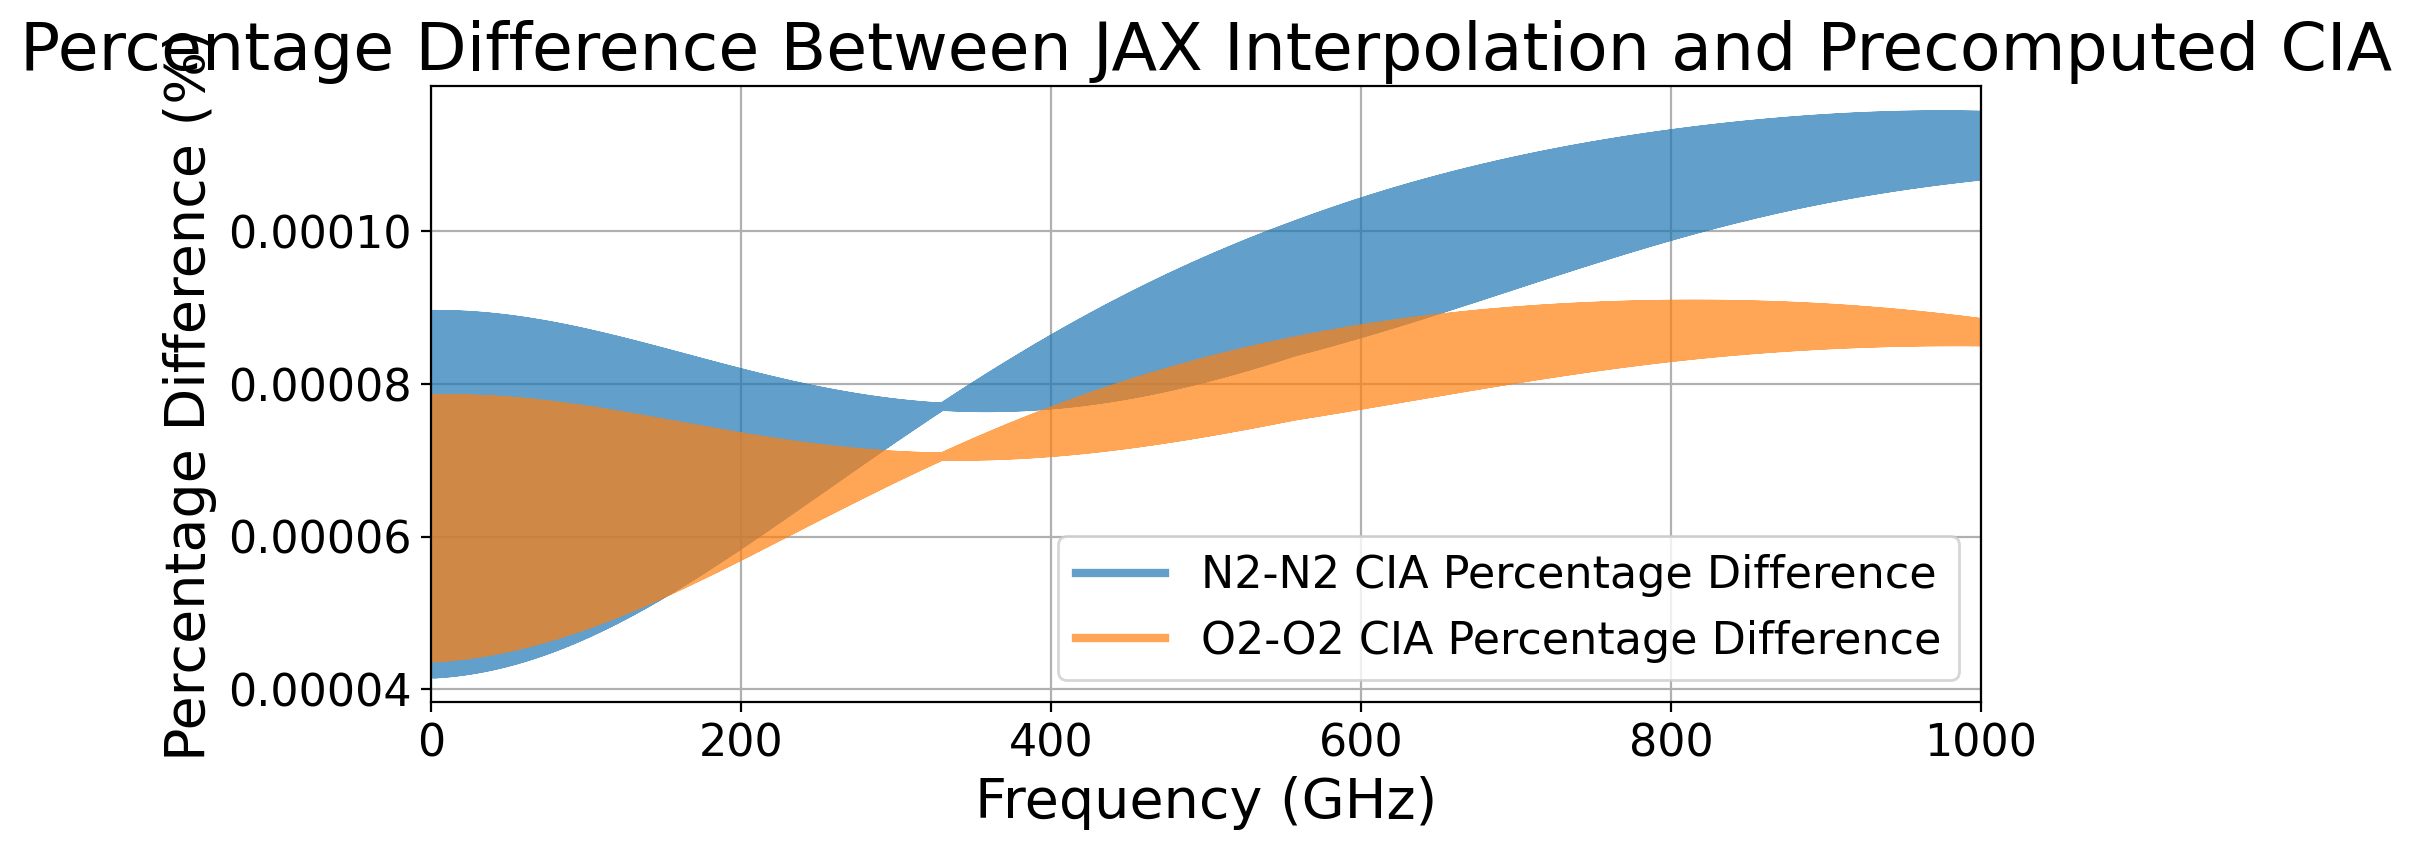

In [72]:
# Let's plot the percentage difference to visually confirm it's negligible across the spectrum
plt.figure(figsize=(10,4),dpi=200)
plt.plot(freqs_GHz [mask], difference_N2N2 [mask], label='N2-N2 CIA Percentage Difference', alpha=0.7)
plt.plot(freqs_GHz [mask], difference_O2O2 [mask], label='O2-O2 CIA Percentage Difference', alpha=0.7)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Percentage Difference (%)')
plt.title('Percentage Difference Between JAX Interpolation and Precomputed CIA')
plt.legend()
plt.xlim(0, 1000)
#plt.yscale('log')
plt.grid()
plt.show()